# Helper Functions

In [7]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/home/danilach/mipt-stats/SberTs')

%load_ext autoreload
%autoreload 2

from utils.models import DummyConditionalModel, VARModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import numpy as np
from collections import defaultdict
from typing import List, Dict, Any, Type
import pandas as pd
import itertools

import pmdarima as pm
from pathlib import Path
import os


def _calculate_mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan

    y_true_safe = y_true[non_zero_mask]
    y_pred_safe = y_pred[non_zero_mask]

    return np.mean(np.abs((y_true_safe - y_pred_safe) / y_true_safe)) * 100


def cross_validate_model(
    model_class: Type,
    df: pd.DataFrame,
    horizon: int,
    stride: int,
    start_window: int,
    target_columns: List[str],
    model_params: Dict[str, Any],
) -> Dict[str, List[float]]:
    errors = defaultdict(list)
    max_train_end_index = len(df) - horizon
    current_train_end_index = start_window

    fold_count = 0
    while current_train_end_index <= max_train_end_index:
        fold_count += 1

        df_train = df.iloc[:current_train_end_index]

        model = model_class(df_train, **model_params)

        for conditioning_col in target_columns:
            conditioning_idx = current_train_end_index + horizon - 1
            conditioning_val = df.loc[df.index[conditioning_idx], conditioning_col]

            predicted_cols, predicted_series = model.make_prediction(
                horizon=horizon, columns=[conditioning_col], values=[conditioning_val]
            )

            for i, pred_col in enumerate(predicted_cols):
                start_val_idx = current_train_end_index
                end_val_idx = current_train_end_index + horizon
                actual_vals = df[pred_col].iloc[start_val_idx:end_val_idx].values

                predicted_vals = predicted_series[i]

                mape = _calculate_mape(actual_vals, predicted_vals)
                if not np.isnan(mape):
                    errors[pred_col].append(mape)

        current_train_end_index += stride

    return dict(errors)


def calc_avg_error(cv_errors):
    ans = {}
    for column, error_list in cv_errors.items():
        avg_mape = np.mean(error_list)
        ans[column] = avg_mape

    return ans


def build_error_matrix(
    model_class: Type,
    df: pd.DataFrame,
    horizon: int,
    stride: int,
    start_window: int,
    model_params: Dict[str, Any],
) -> pd.DataFrame:
    all_columns = df.columns.tolist()

    error_matrix = pd.DataFrame(index=all_columns, columns=all_columns, dtype=float)
    error_matrix.index.name = "Conditioning Variable"
    error_matrix.columns.name = "Predicted Variable"

    for conditioning_col in all_columns:
        cv_errors = cross_validate_model(
            model_class=model_class,
            df=df,
            horizon=horizon,
            stride=stride,
            start_window=start_window,
            target_columns=[conditioning_col],
            model_params=model_params,
        )

        avg_errors = calc_avg_error(cv_errors)

        for predicted_col, avg_error in avg_errors.items():
            error_matrix.loc[conditioning_col, predicted_col] = avg_error

    return error_matrix


def build_short_error_matrix(
    model_class: Type,
    df: pd.DataFrame,
    horizon: int,
    stride: int,
    start_window: int,
    model_params: Dict[str, Any],
) -> pd.DataFrame:

    all_columns = df.columns.tolist()

    error_matrix = pd.DataFrame(index=all_columns, columns=all_columns, dtype=float)
    error_matrix.index.name = "Conditioning Variable"
    error_matrix.columns.name = "Predicted Variable"

    avg_errors = 0
    for conditioning_col in all_columns[:1]:
        cv_errors = cross_validate_model(
            model_class=model_class,
            df=df,
            horizon=horizon,
            stride=stride,
            start_window=start_window,
            target_columns=[conditioning_col],
            model_params=model_params,
        )

        avg_errors = calc_avg_error(cv_errors)

        for predicted_col, avg_error in avg_errors.items():
            error_matrix.loc[conditioning_col, predicted_col] = avg_error

    for conditioning_col in all_columns[1:]:
        for predicted_col, avg_error in avg_errors.items():
            error_matrix.loc[conditioning_col, predicted_col] = avg_error

    return error_matrix

# Model

In [9]:
from typing import List, Tuple
import pandas as pd
import numpy as np
from sktime.forecasting.var_reduce import VARReduce


class VARReduceLinExtr:
    """
    Conditional forecasting model using sktime's VARReduce (VAR from statsmodels).

    Interface:
      - __init__(df: pd.DataFrame, **kwargs)
      - make_prediction(horizon: int, columns: List[str], values: List[float])
          -> (predicted_columns: List[str], predictions: List[List[float]])
    """

    def __init__(self, df: pd.DataFrame, **kwargs):
        self.df = df.copy()
        self.all_columns = df.columns.tolist()
        self.forecaster = VARReduce(**kwargs)

        self.forecaster.fit(self.df)

    def make_prediction(
        self, horizon: int, columns: List[str], values: List[float]
    ) -> Tuple[List[str], List[List[float]]]:
        fh = np.arange(1, horizon + 1) 
        y_pred = self.forecaster.predict(fh=fh)

        adjusted_preds = y_pred.copy()

        for col, target in zip(columns, values):
            if col not in adjusted_preds.columns:
                raise KeyError(f"Column {col} not in data")

            baseline = adjusted_preds[col].to_numpy()
            pred_final = baseline[-1]
            shift_total = target - pred_final
            # add linear adjustment
            shifts = [(shift_total * (t / horizon)) for t in range(1, horizon + 1)]
            adjusted_preds[col] = baseline + np.array(shifts)

        predicted_cols = adjusted_preds.columns.tolist()
        predicted_series_list = [adjusted_preds[col].tolist() for col in predicted_cols]

        return predicted_cols, predicted_series_list

# Chemicals

In [10]:
data_path = "/home/danilach/mipt-stats/SberTs/Data/chemicals_nona.csv"
df = pd.read_csv(data_path, index_col=0)
df.index = pd.to_datetime(df.index)

In [11]:
from sklearn.linear_model import Lasso, Ridge

In [12]:
# param_grid = {
#     "regressor": [
#         None,
#         Lasso(alpha=0.05, max_iter=20000),
#         Ridge(alpha=0.05, max_iter=20000),
#         Lasso(alpha=0.5, max_iter=20000),
#         Ridge(alpha=0.5, max_iter=20000),
#         Lasso(alpha=2, max_iter=20000),
#         Ridge(alpha=2, max_iter=20000),
#         Lasso(alpha=5, max_iter=20000),
#         Ridge(alpha=5, max_iter=20000),
#         Lasso(alpha=10, max_iter=20000),
#         Lasso(alpha=30, max_iter=20000),
#     ],
#     "lags": [1, 2],
# }

# param_keys = list(param_grid.keys())
# param_combinations = list(itertools.product(*param_grid.values()))
# best_metric = float("inf")
# best_params = None
# best_horizon = None
# best_err_mat = None
# horizon_list = [12]
# stride = 4
# start_window = 60
# model_class = VARReduceLinExtr


# for combo in param_combinations:
#     model_params = dict(zip(param_keys, combo))
#     err_mat = build_short_error_matrix(
#         model_class=model_class,
#         df=df,
#         horizon=12,
#         stride=stride,
#         start_window=start_window,
#         model_params=model_params,
#     )
#     metric = np.mean(err_mat)
#     if metric < best_metric:
#         best_metric = metric
#         best_params = model_params.copy()
#         best_err_mat = err_mat.copy()

# print(f"New best metric: {best_metric:.4f}")
# print(f"Best params: {best_params}")

In [13]:
matrix_params = {
    "model_class": VARReduceLinExtr,
    "df": df,
    "horizon": 12,
    "stride": 4,
    "start_window": 60,
    "model_params": {
        "regressor": Lasso(alpha=30, max_iter=20000),
        "lags": 1,
    },
}
horizon_list = [12, 24, 36, 48]


for horizon in horizon_list:
    matrix_params["horizon"] = horizon
    err_mat = build_error_matrix(**matrix_params)
    output_dir = "/home/danilach/mipt-stats/SberTs/results/var_reduce_chemicals"
    os.makedirs(output_dir, exist_ok=True)
    output_path = f"{output_dir}/err_mat_{horizon}_{matrix_params["model_params"].values()}.csv"
    err_mat.to_csv(output_path, index=True)

### Матрицы

39.08696177974139


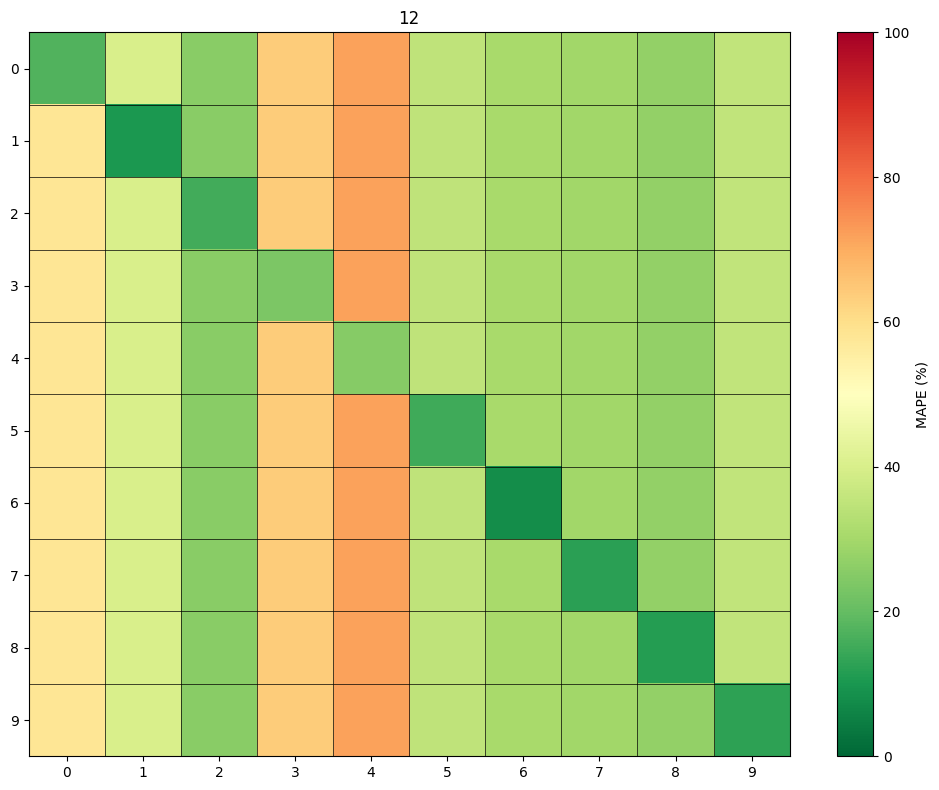

118.14159774951972


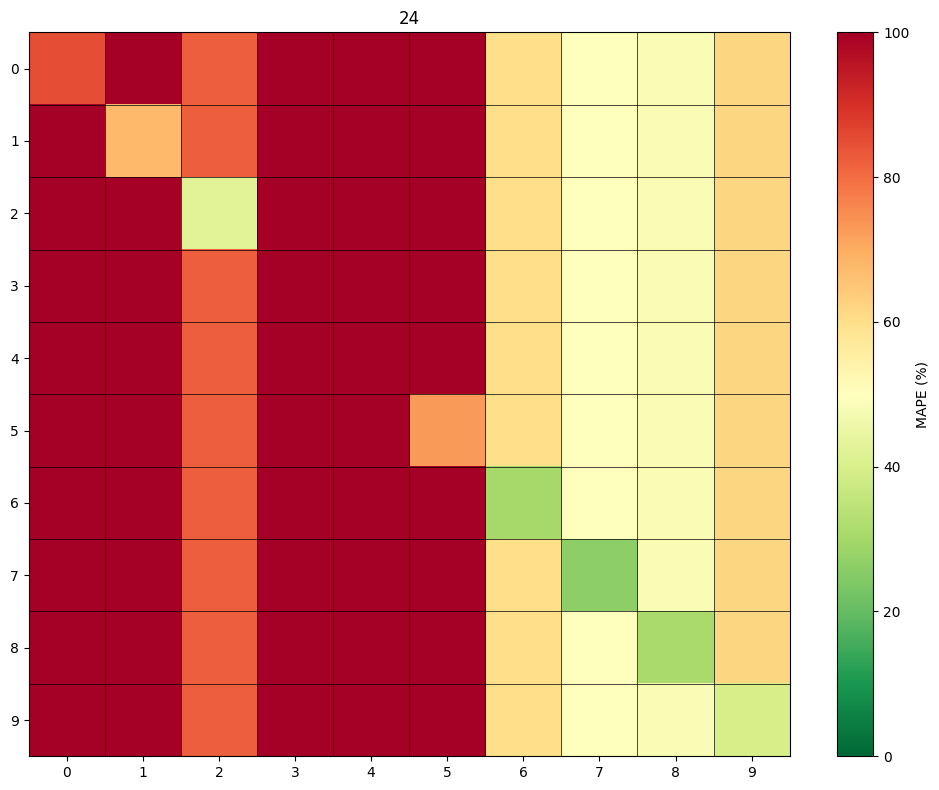

427.5768693481774


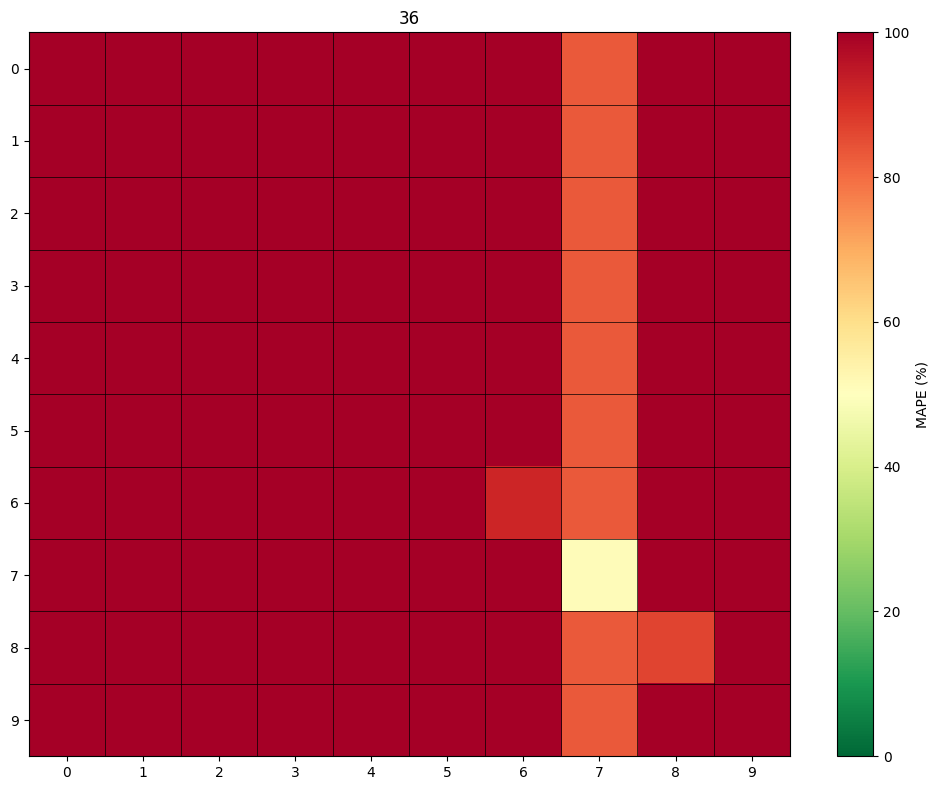

31.63730429053


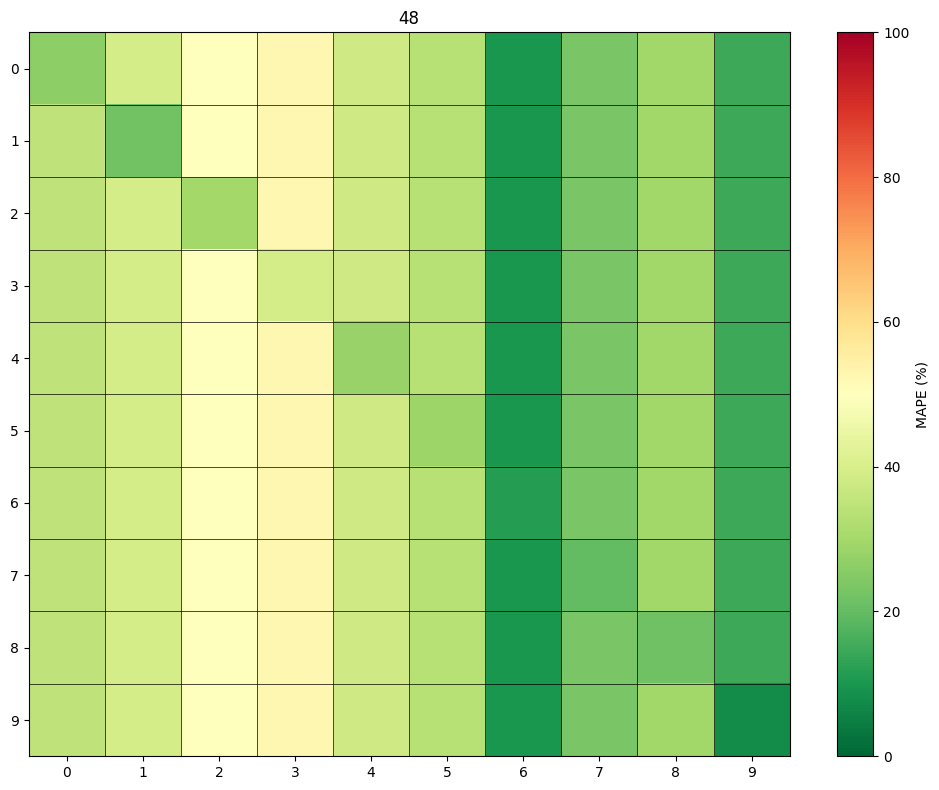

In [14]:
for horizon in horizon_list:
    file_path = f"/home/danilach/mipt-stats/SberTs/results/var_reduce_chemicals/err_mat_{horizon}_dict_values([Lasso(alpha=30, max_iter=20000), 1]).csv"
    err_mat = pd.read_csv(file_path, index_col=0)
    print(np.mean(err_mat))
    plot_error_matrix(err_mat, title=f"{horizon}")

Опять наблюдаем странность что на горизонте 4 года ошибка лучше чем на горизонте 1 и куда лучше чем на горизонте 2 и 3 года

In [15]:
import matplotlib.pyplot as plt

In [33]:
avg_mape_list = []

for horizon in range(2, 54, 1):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    avg_mape_list.append(np.mean(error_matrix))

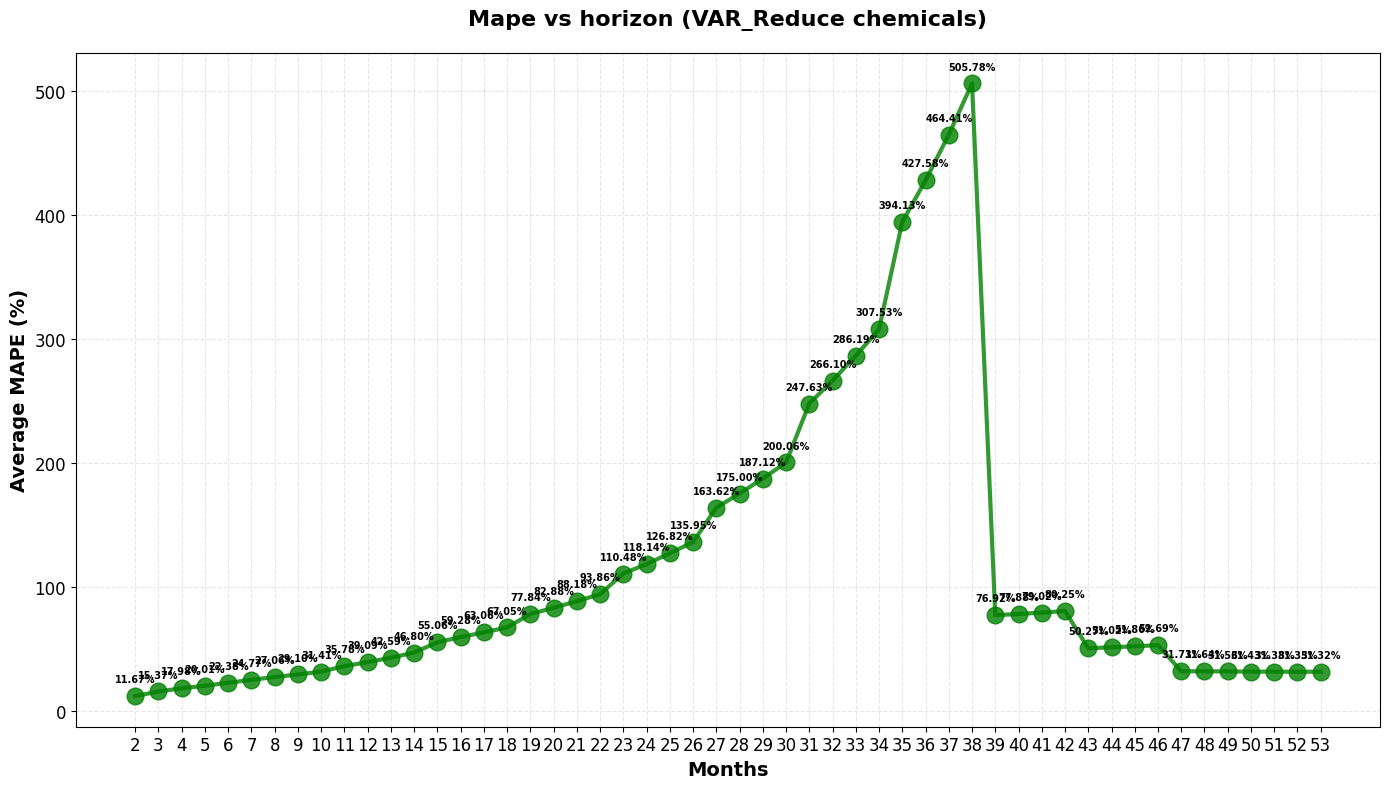

In [34]:
plt.figure(figsize=(14, 8))
plt.plot(
    np.arange(2, 54, 1),
    avg_mape_list,
    marker="o",
    markersize=12,
    color="g",
    linewidth=3,
    linestyle="-",
    alpha=0.8,
)
plt.title("Mape vs horizon (VAR_Reduce chemicals)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("Average MAPE (%)", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 54, 1), fontsize=12)
plt.yticks(fontsize=12)

for i, (x, y) in enumerate(zip(np.arange(2, 54, 1), avg_mape_list)):
    plt.annotate(
        f"{y:.2f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=7,
        fontweight="bold",
    )


plt.tight_layout()
plt.show()

### Ряды

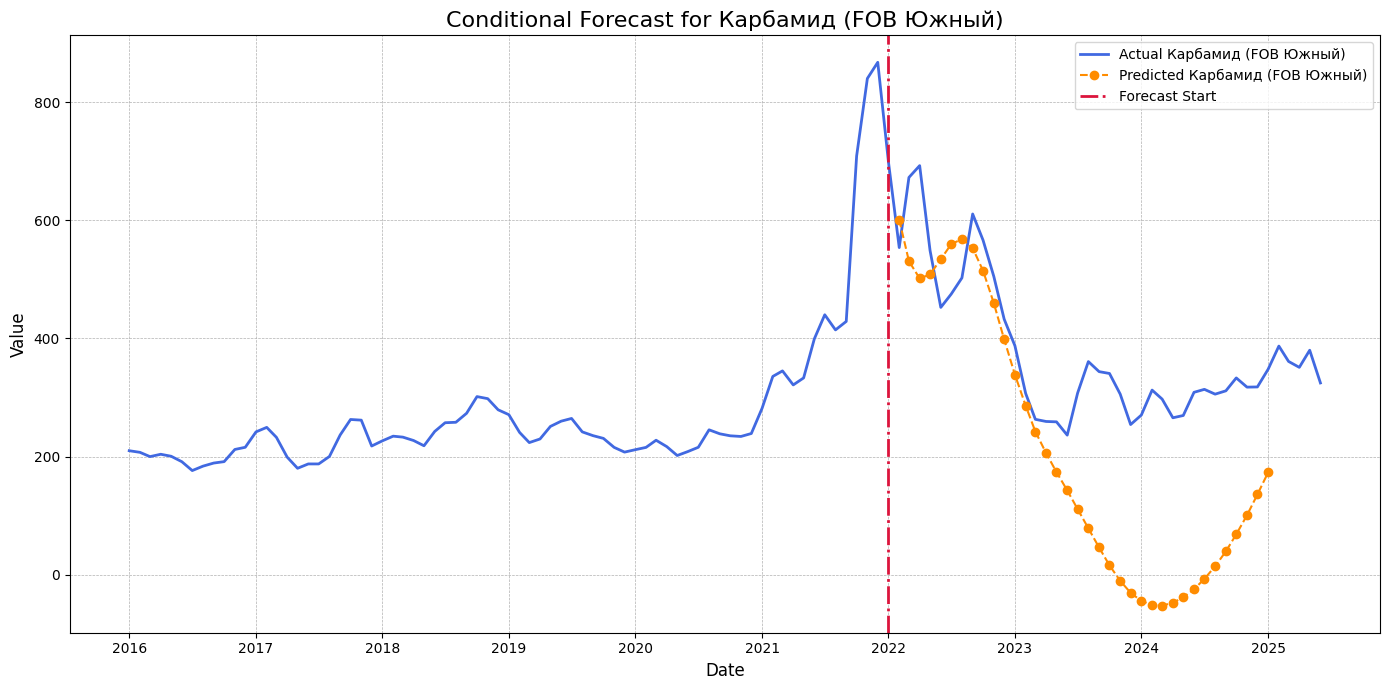

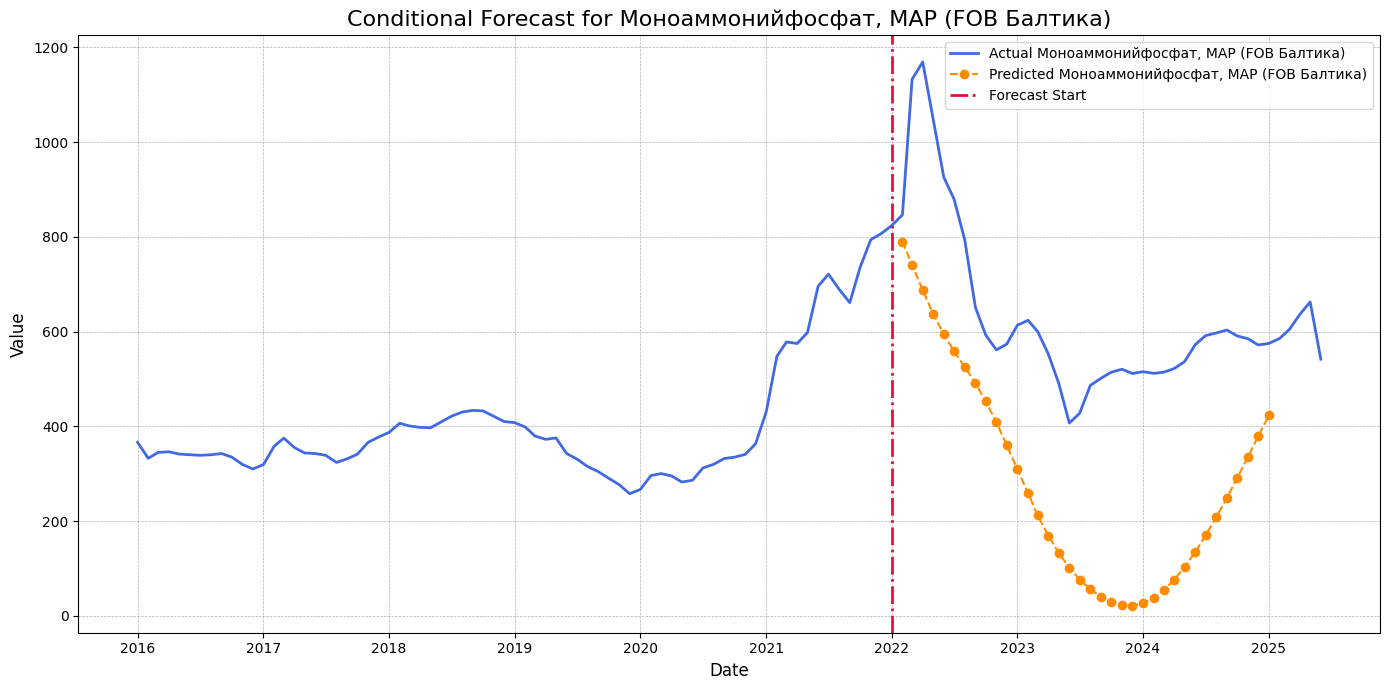

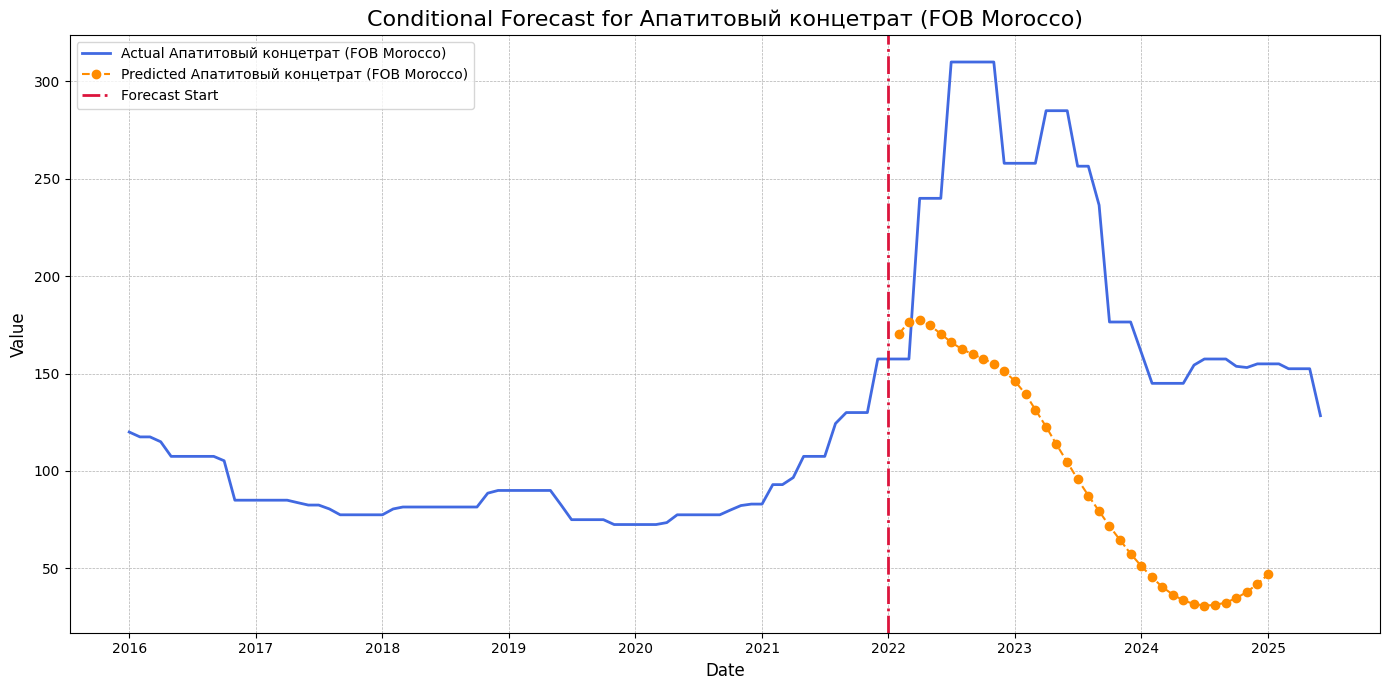

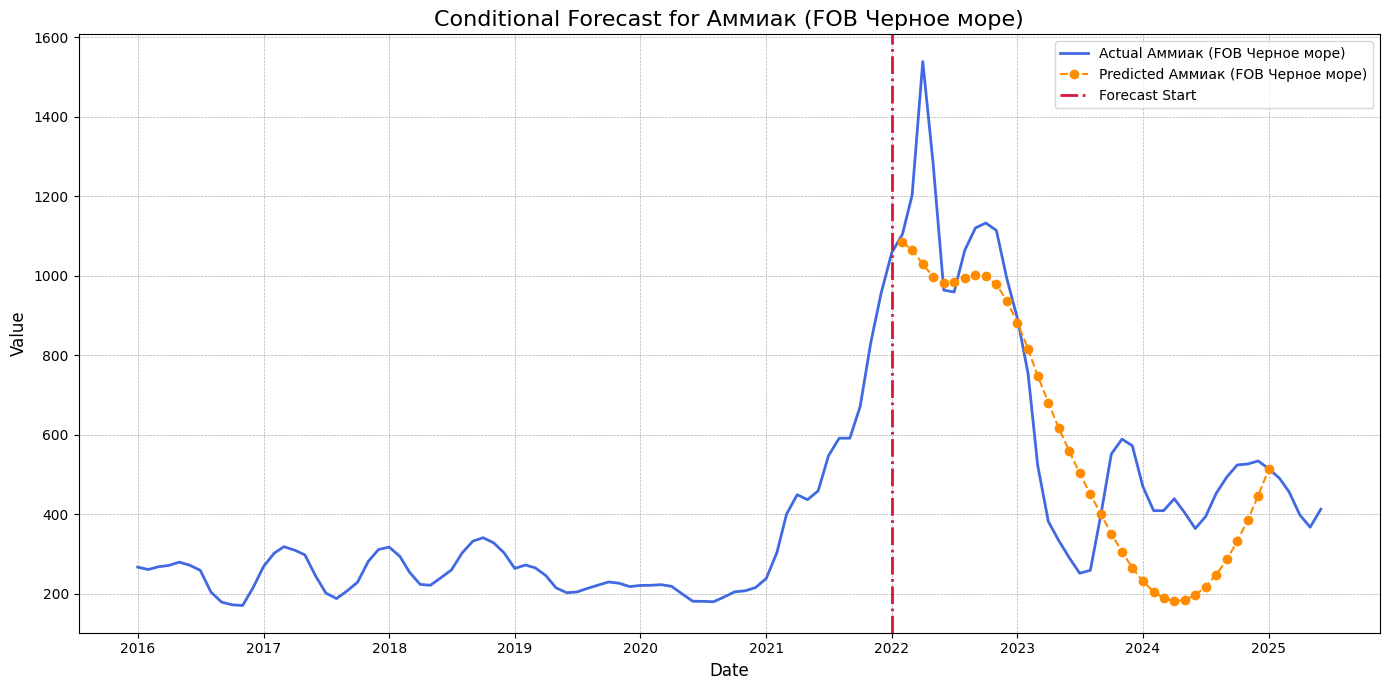

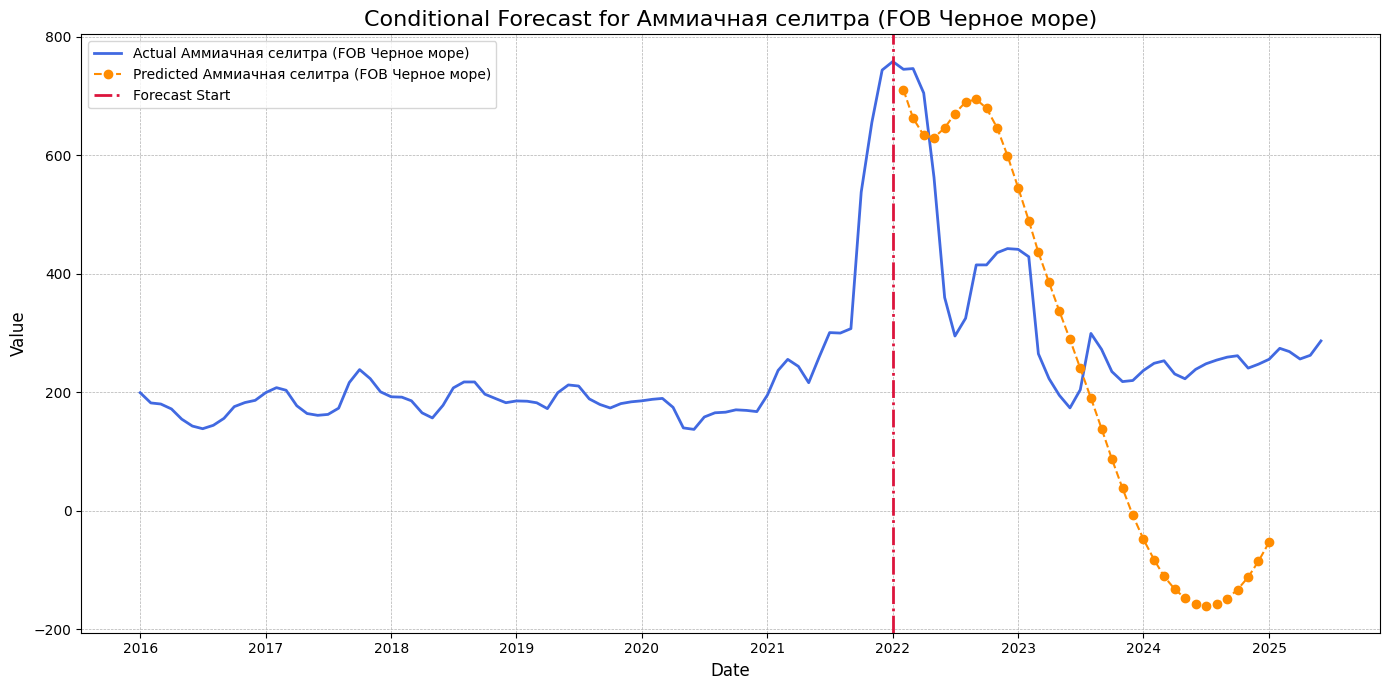

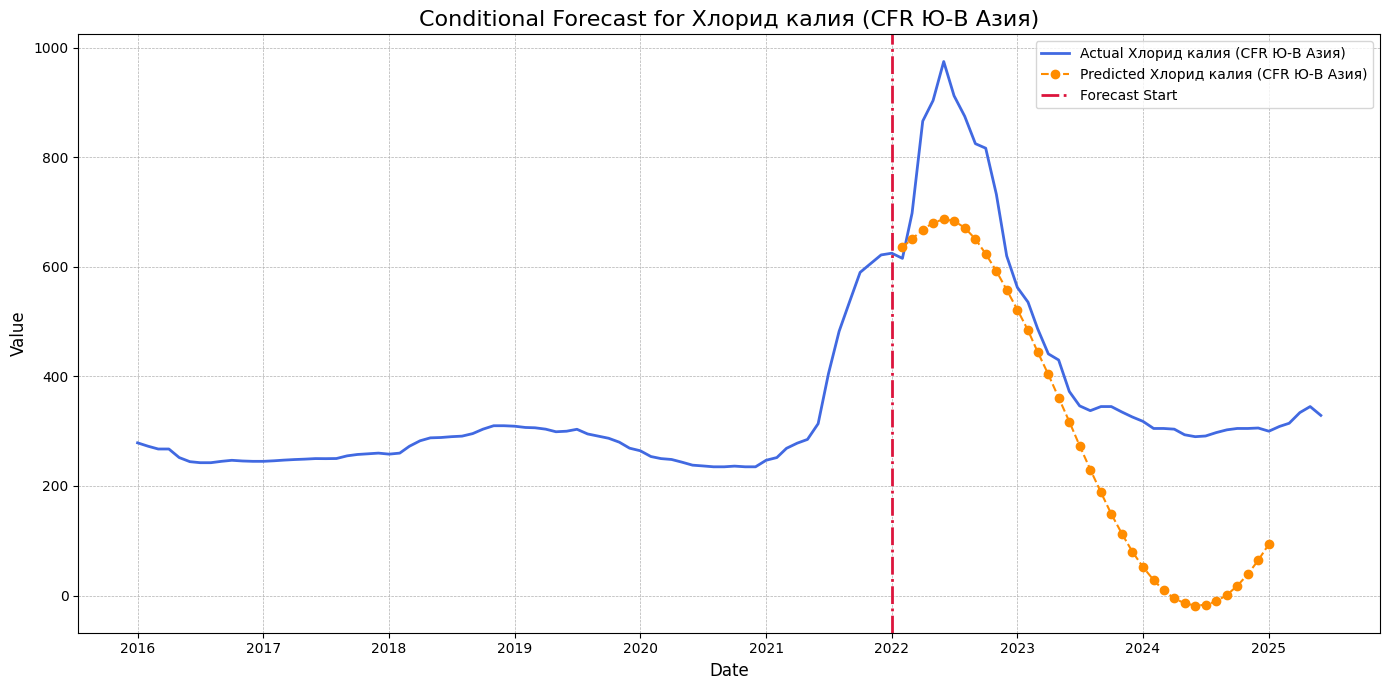

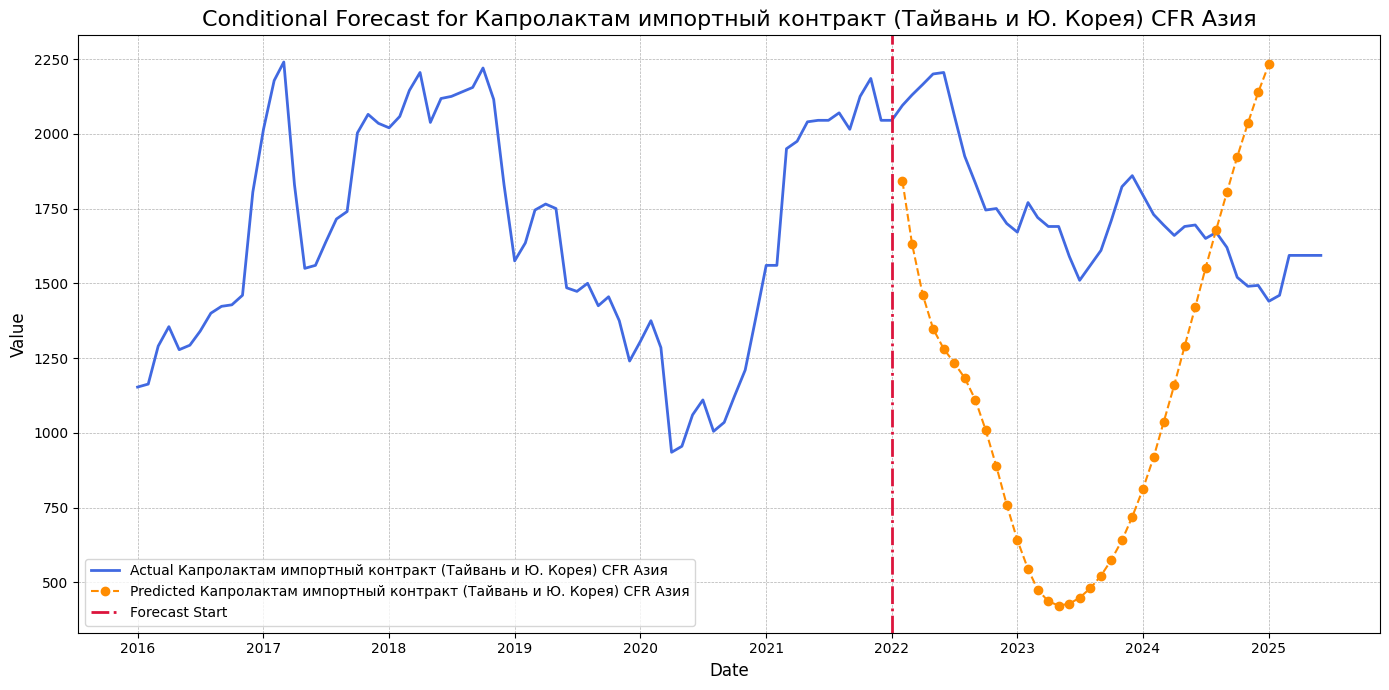

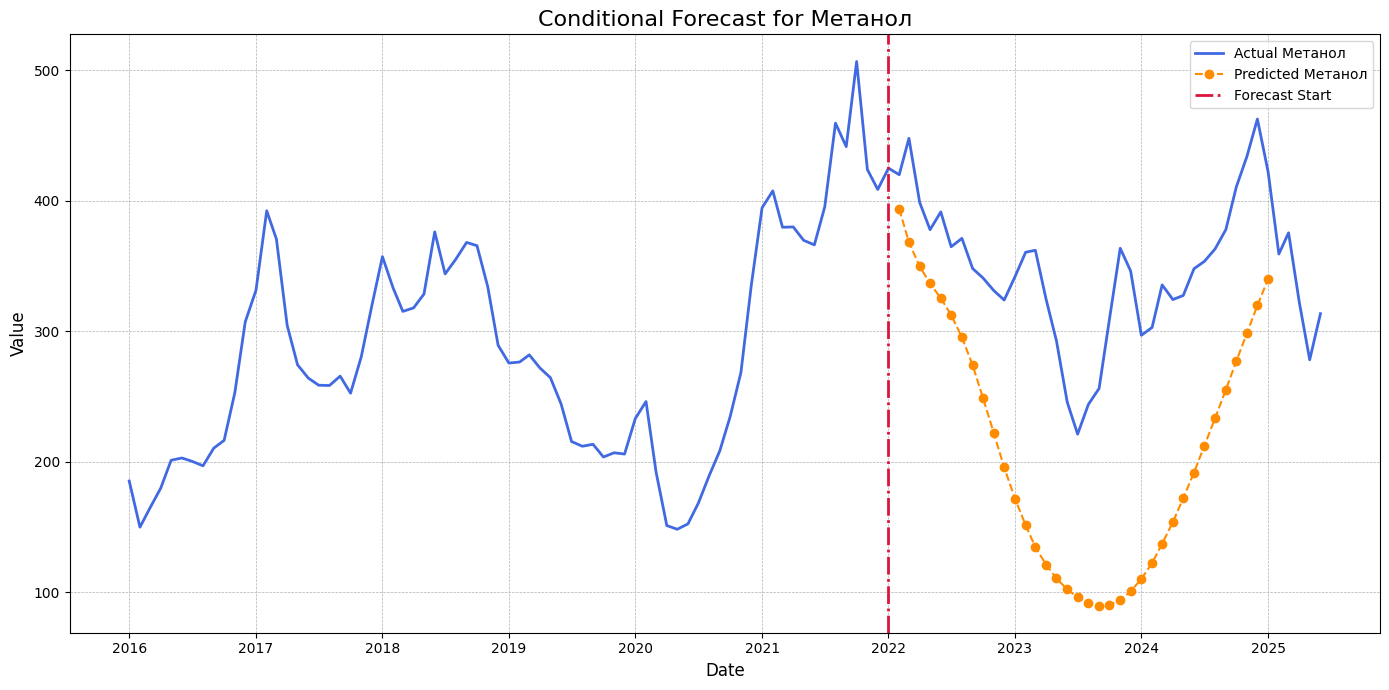

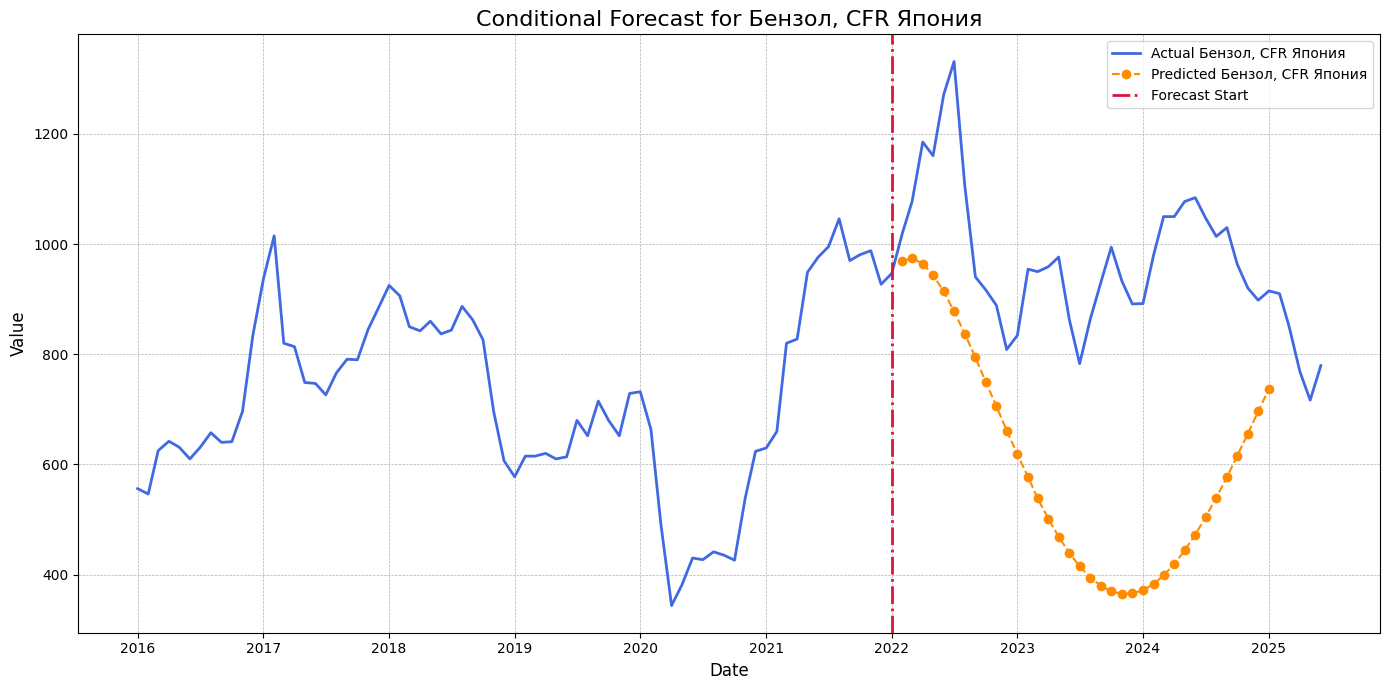

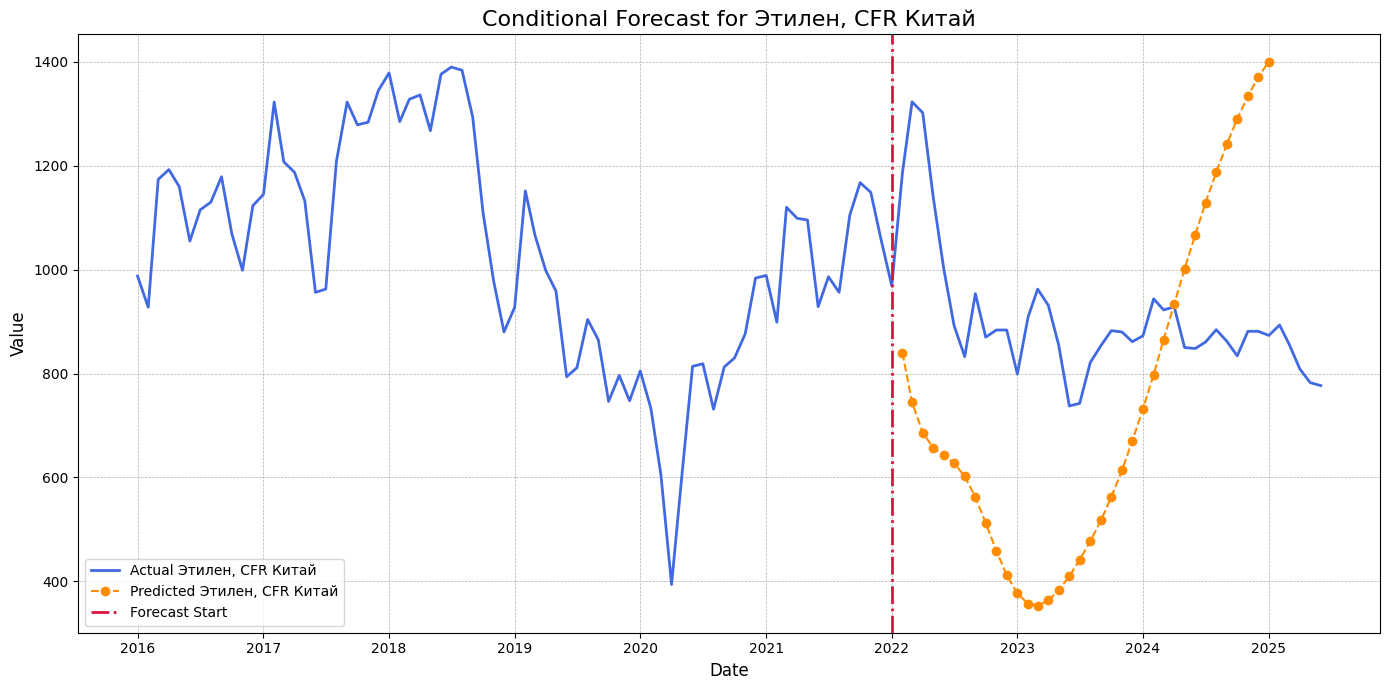

In [ ]:
plot_model_pred(
    model_class=VARReduceLinExtr,
    df=df,
    model_params={
        "regressor": Lasso(alpha=30, max_iter=20000),
        "lags": 1,
    },
    conditioning_col=df.columns[3],
    horizon=36,
    cutoff_date="2022-01-01",
)

# APK

In [35]:
data_path = "/home/danilach/mipt-stats/SberTs/Data/apk_nona.csv"
df = pd.read_csv(data_path, index_col=0)
df.index = pd.to_datetime(df.index)

In [ ]:
param_grid = {
    "regressor": [
        None,
        Lasso(alpha=0.05, max_iter=20000),
        Ridge(alpha=0.05, max_iter=20000),
        Lasso(alpha=0.5, max_iter=20000),
        Ridge(alpha=0.5, max_iter=20000),
        Lasso(alpha=2, max_iter=20000),
        Ridge(alpha=2, max_iter=20000),
        Lasso(alpha=5, max_iter=20000),
        Ridge(alpha=5, max_iter=20000),
        Lasso(alpha=10, max_iter=20000),
        Lasso(alpha=30, max_iter=20000),
    ],
    "lags": [1, 2],
}

param_keys = list(param_grid.keys())
param_combinations = list(itertools.product(*param_grid.values()))
best_metric = float("inf")
best_params = None
best_horizon = None
best_err_mat = None
horizon_list = [12]
stride = 4
start_window = 60
model_class = VARReduceLinExtr


for combo in param_combinations:
    model_params = dict(zip(param_keys, combo))
    err_mat = build_short_error_matrix(
        model_class=model_class,
        df=df,
        horizon=12,
        stride=stride,
        start_window=start_window,
        model_params=model_params,
    )
    metric = np.mean(err_mat)
    if metric < best_metric:
        best_metric = metric
        best_params = model_params.copy()
        best_err_mat = err_mat.copy()

print(f"best metric: {best_metric:.4f}")
print(f"Best params: {best_params}")

/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.169e+01, tolerance: 6.717e-01
  model = cd_fast.enet_coordinate_descent(
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.219e-01, tolerance: 7.459e-03
  model = cd_fast.enet_coordinate_descent(
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

New best metric: 78.5696
Best params: {'regressor': Ridge(alpha=5, max_iter=20000), 'lags': 1}


In [ ]:
matrix_params = {
    "model_class": VARReduceLinExtr,
    "df": df,
    "horizon": 12,
    "stride": 4,
    "start_window": 60,
    "model_params": {
        "regressor": Ridge(alpha=20, max_iter=20000),
        "lags": 1,
    },
}
horizon_list = [12, 24, 36, 48]


for horizon in horizon_list:
    matrix_params["horizon"] = horizon
    err_mat = build_short_error_matrix(**matrix_params)
    output_dir = "/home/danilach/mipt-stats/SberTs/results/var_reduce_apk"
    os.makedirs(output_dir, exist_ok=True)
    output_path = f"{output_dir}/err_mat_{horizon}_{matrix_params["model_params"].values()}.csv"
    err_mat.to_csv(output_path, index=True)

In [ ]:
avg_mape_list = []

for horizon in range(2, 54, 2):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    avg_mape_list.append(np.mean(error_matrix))

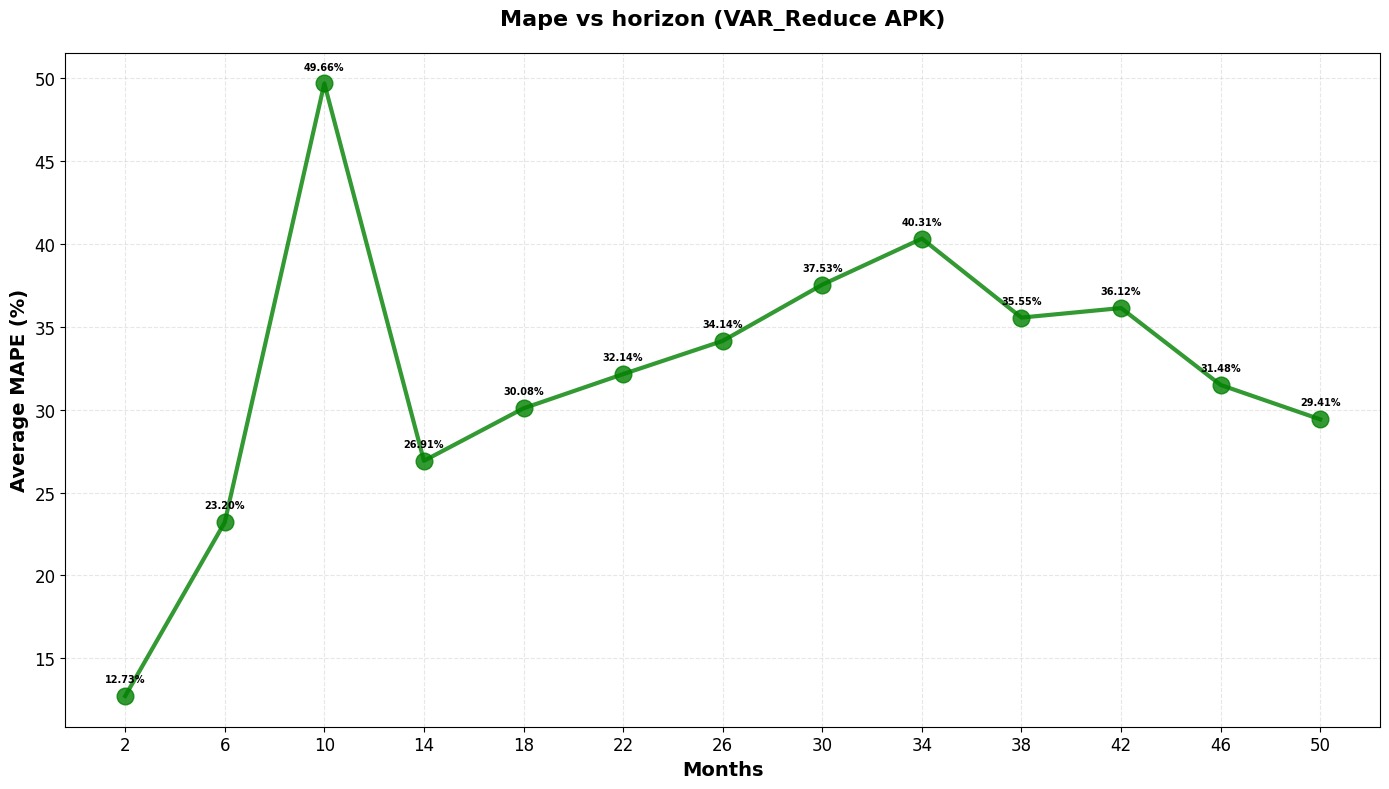

In [39]:
plt.figure(figsize=(14, 8))
plt.plot(
    np.arange(2, 54, 4),
    avg_mape_list,
    marker="o",
    markersize=12,
    color="g",
    linewidth=3,
    linestyle="-",
    alpha=0.8,
)
plt.title("Mape vs horizon (VAR_Reduce APK)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("Average MAPE (%)", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 54, 4), fontsize=12)
plt.yticks(fontsize=12)

for i, (x, y) in enumerate(zip(np.arange(2, 54, 4), avg_mape_list)):
    plt.annotate(
        f"{y:.2f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=7,
        fontweight="bold",
    )


plt.tight_layout()
plt.show()

### Матрицы

78.56955524391005


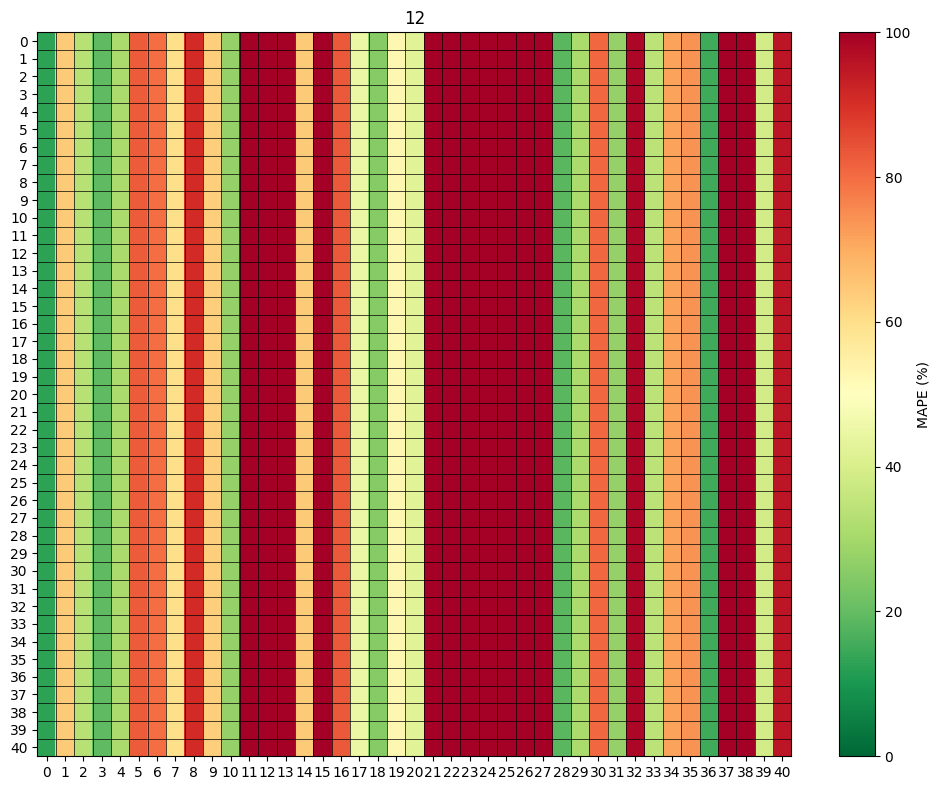

33.844649958968944


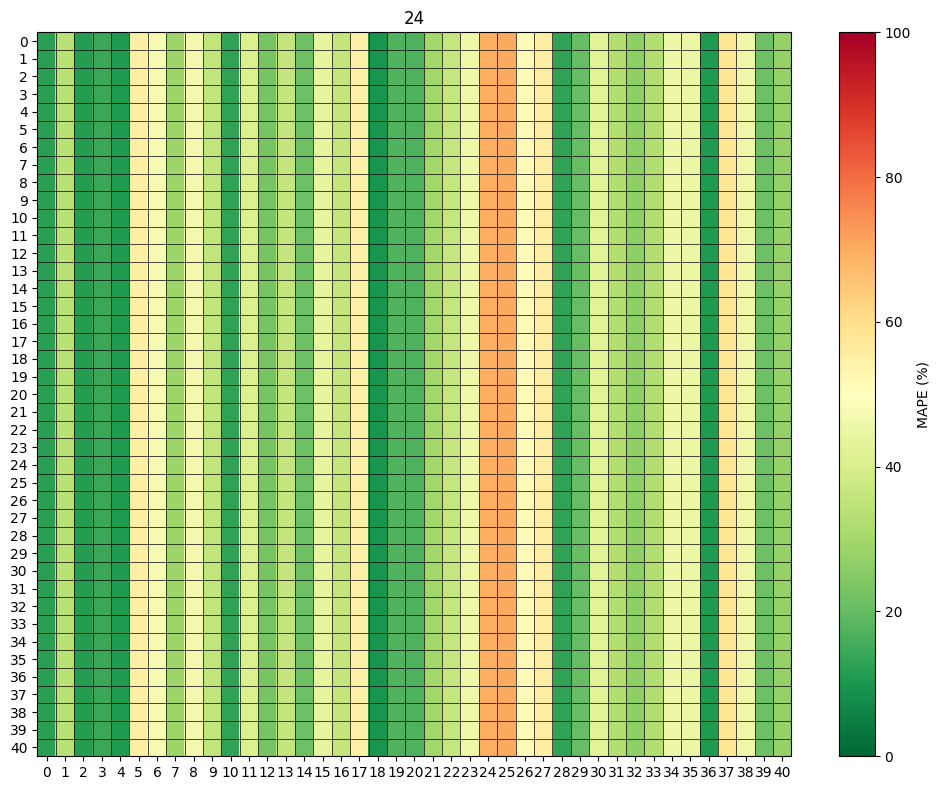

41.943752253758085


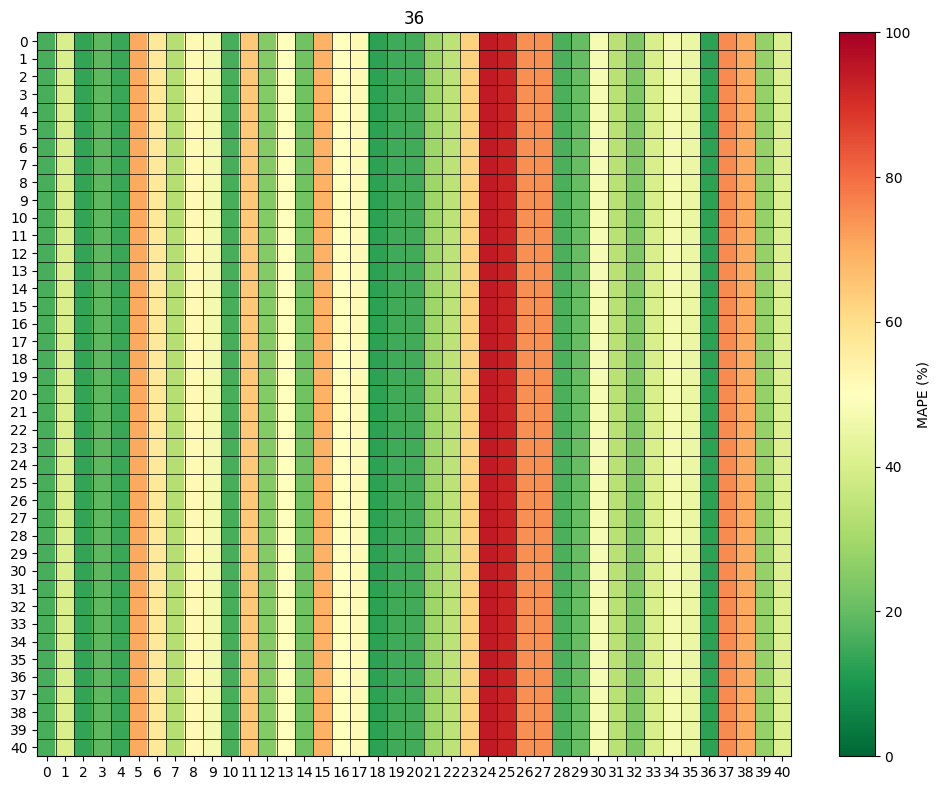

31.871323529385446


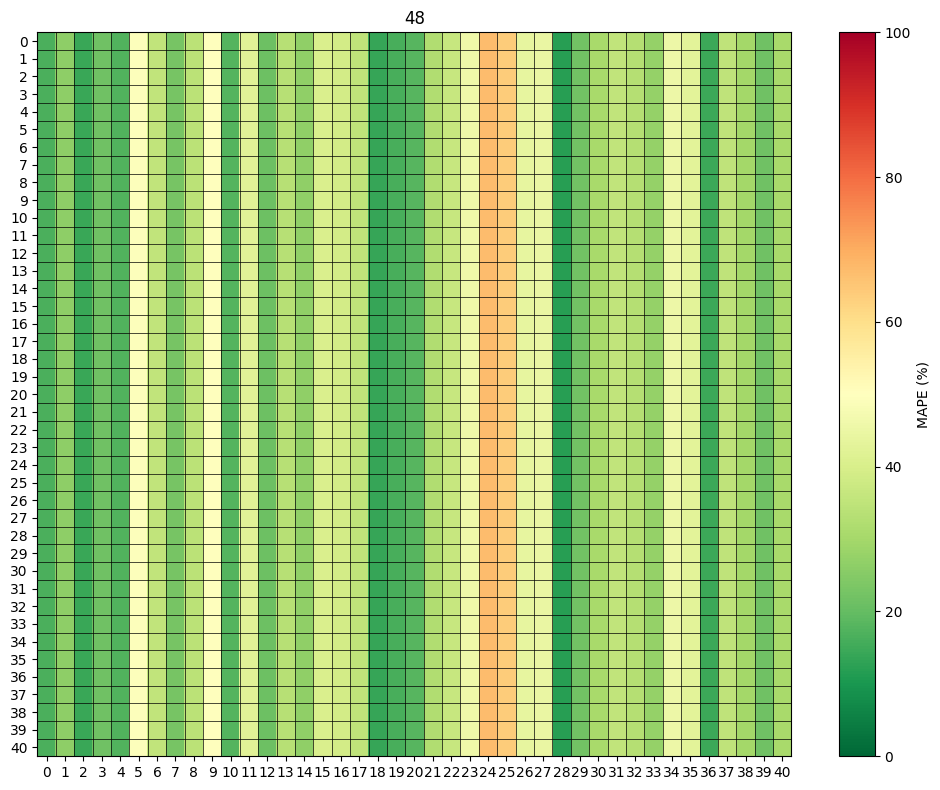

In [ ]:
for horizon in horizon_list:
    file_path = f"/home/danilach/mipt-stats/SberTs/results/var_reduce_apk/err_mat_{horizon}_dict_values([Ridge(alpha=5, max_iter=20000), 1]).csv"
    err_mat = pd.read_csv(file_path, index_col=0)
    print(np.mean(err_mat))
    plot_error_matrix(err_mat, title=f"{horizon}")

### Ряды

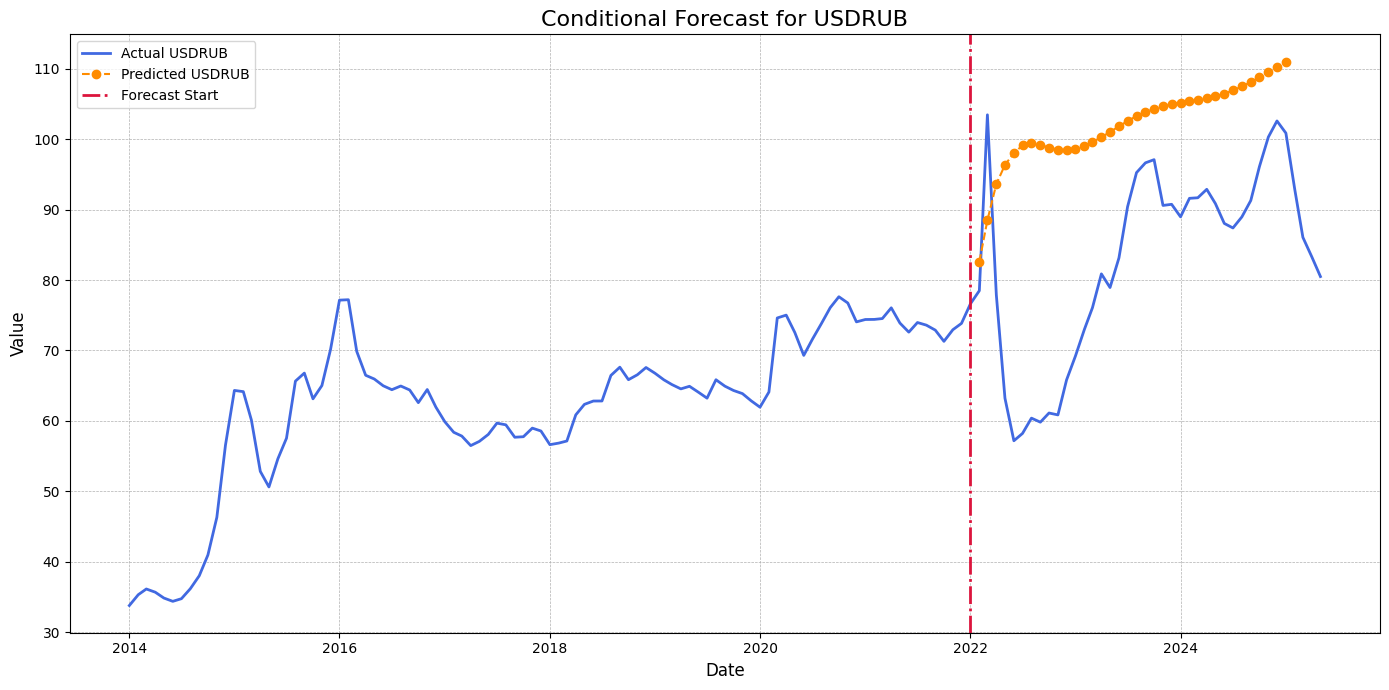

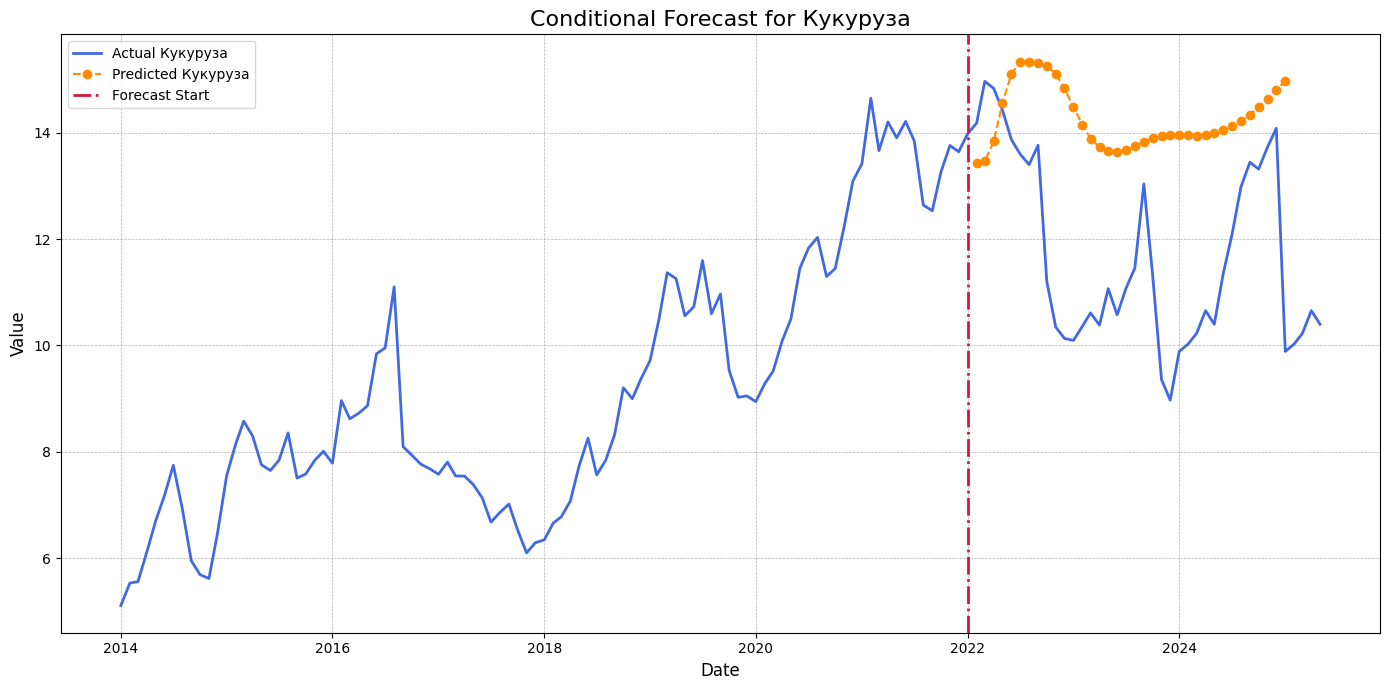

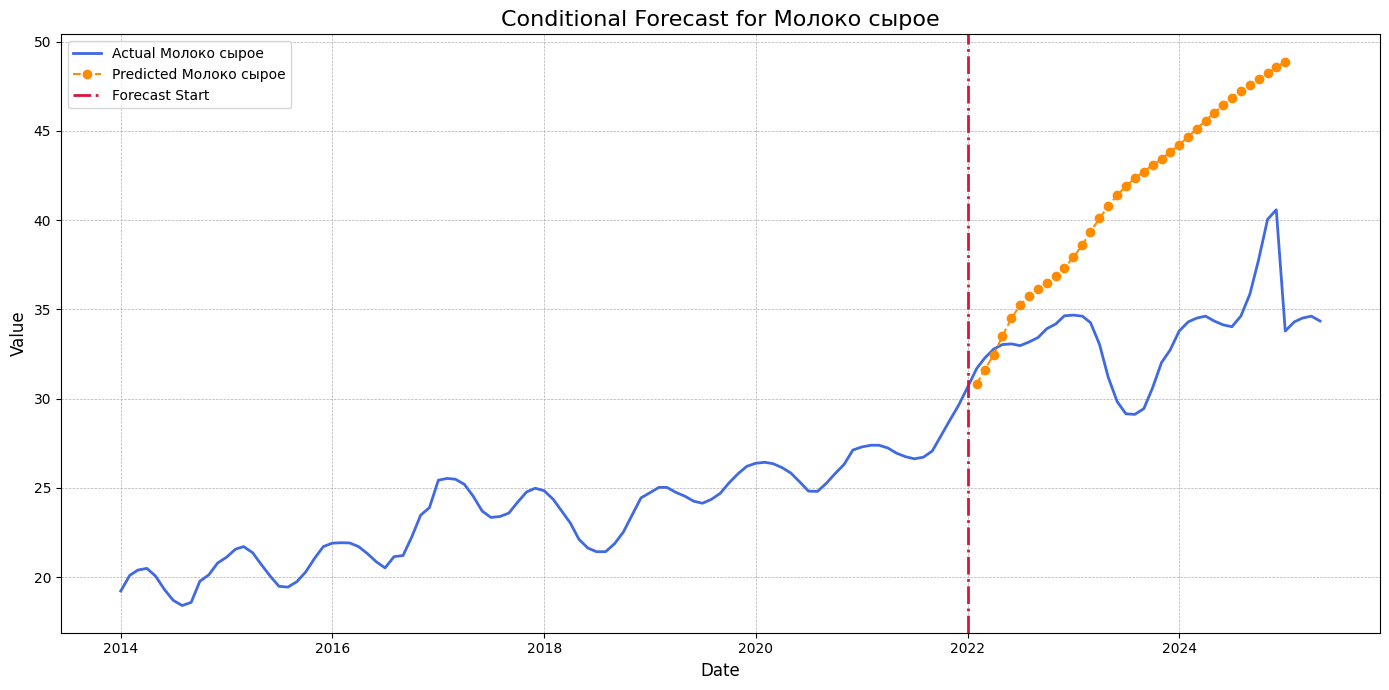

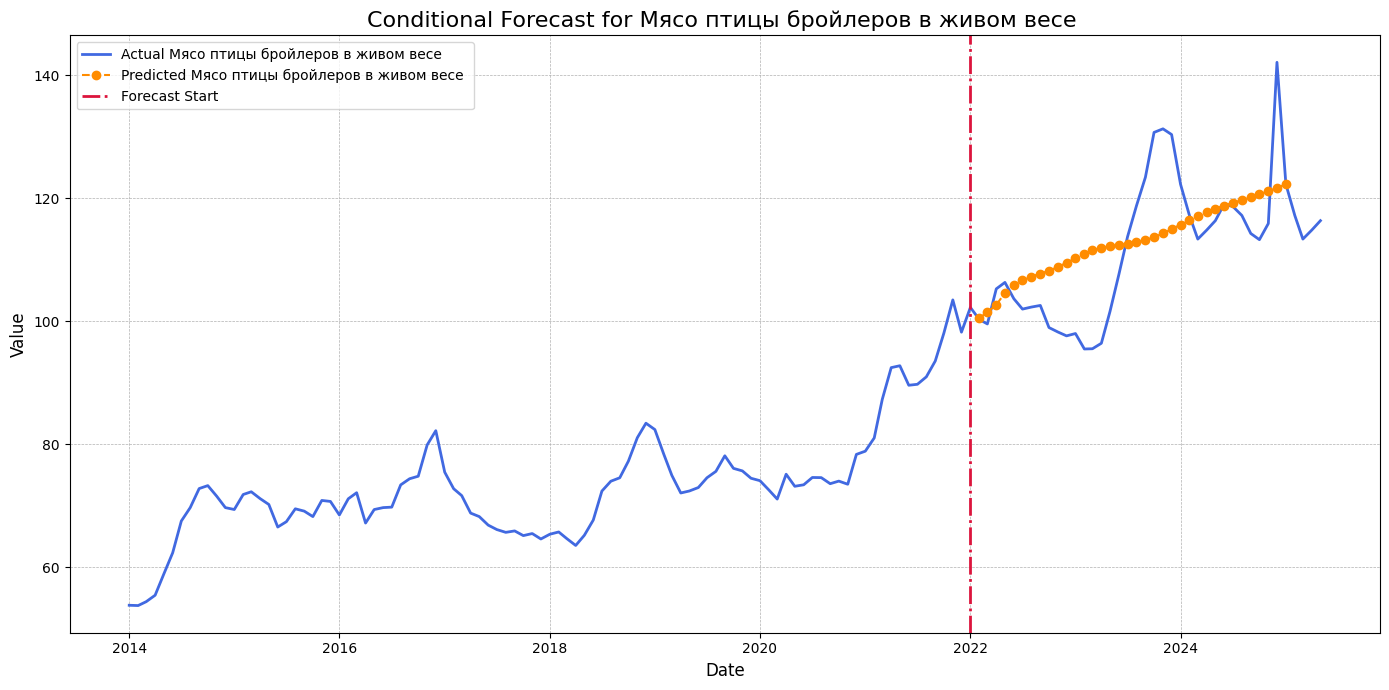

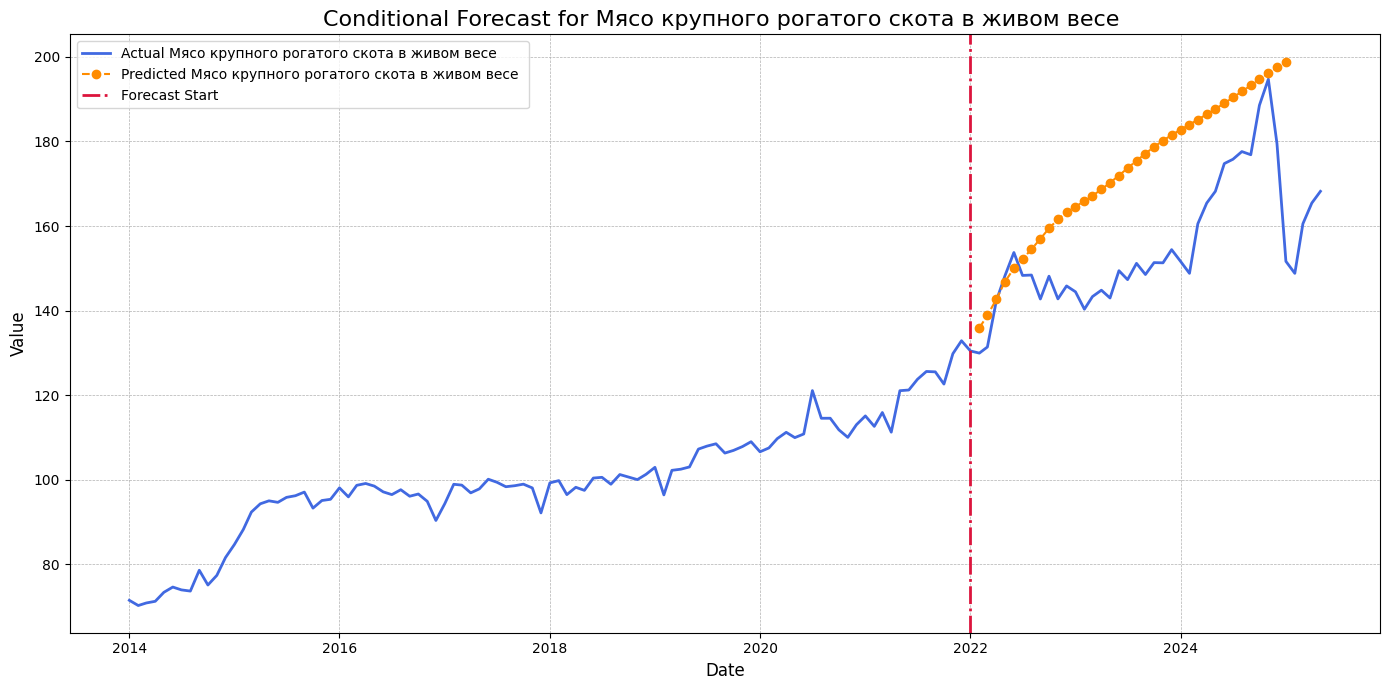

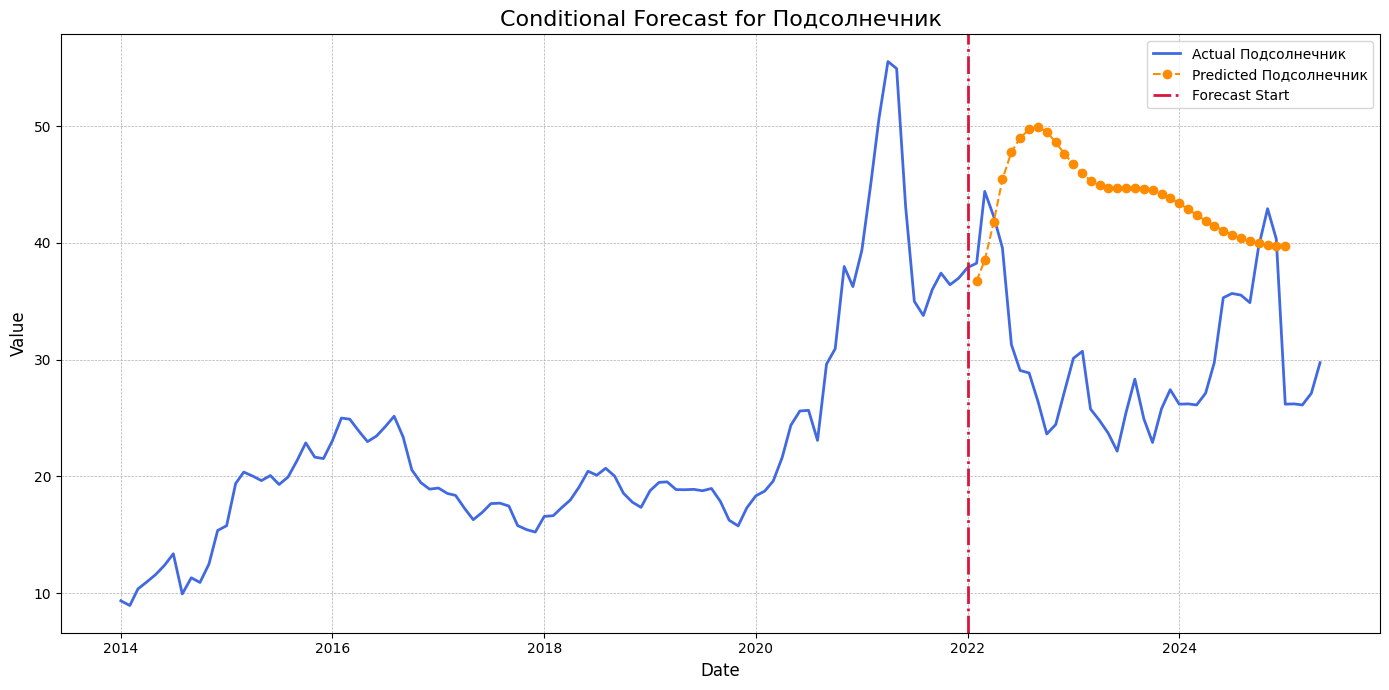

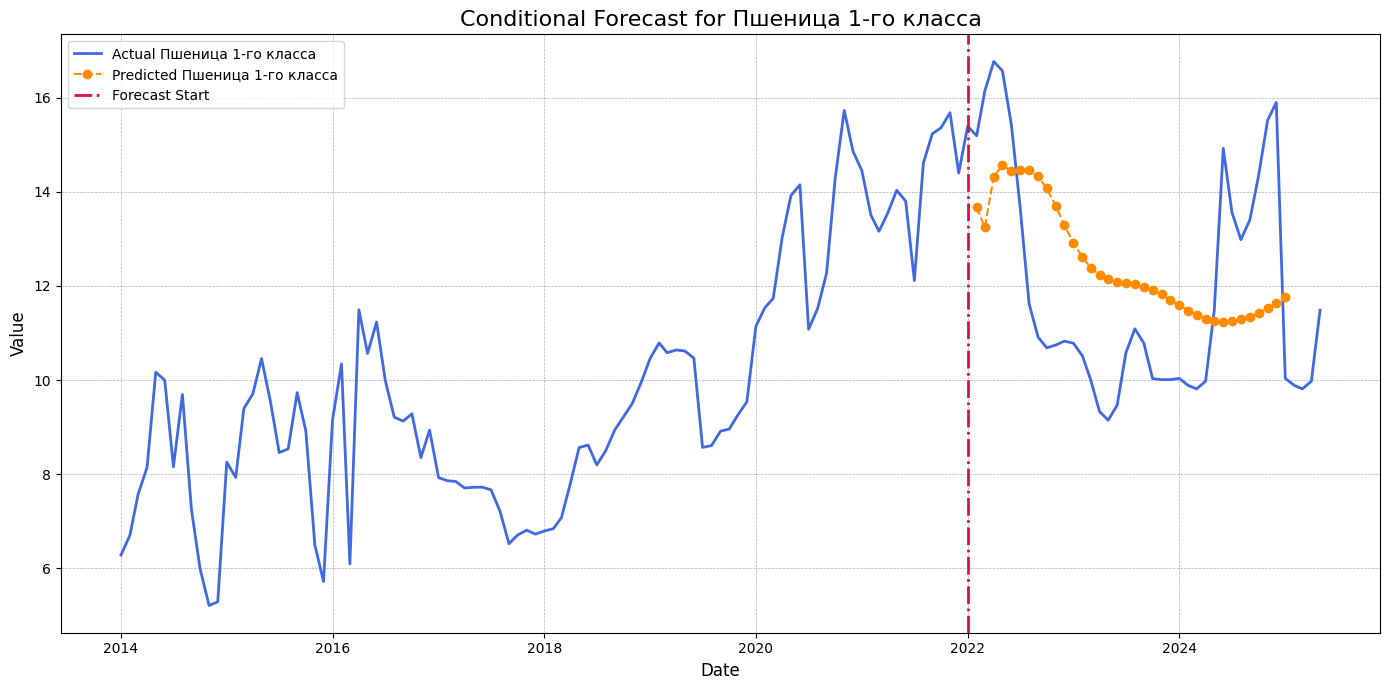

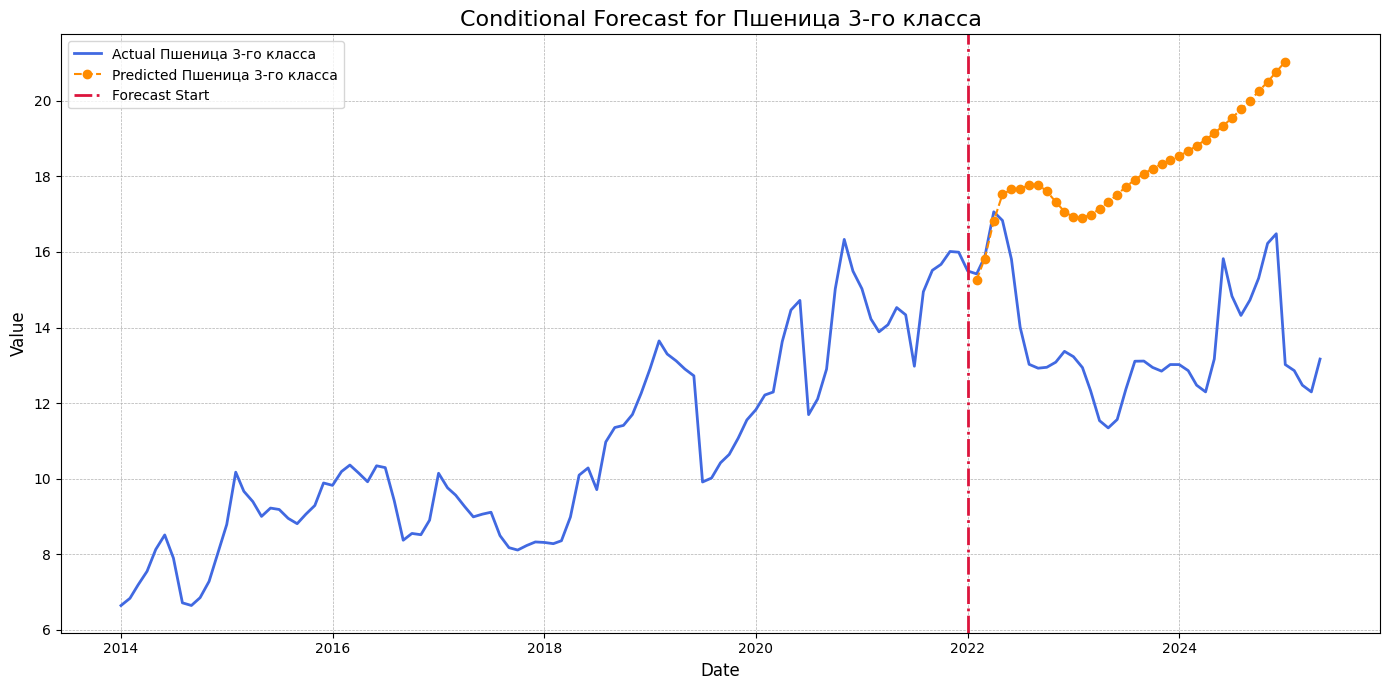

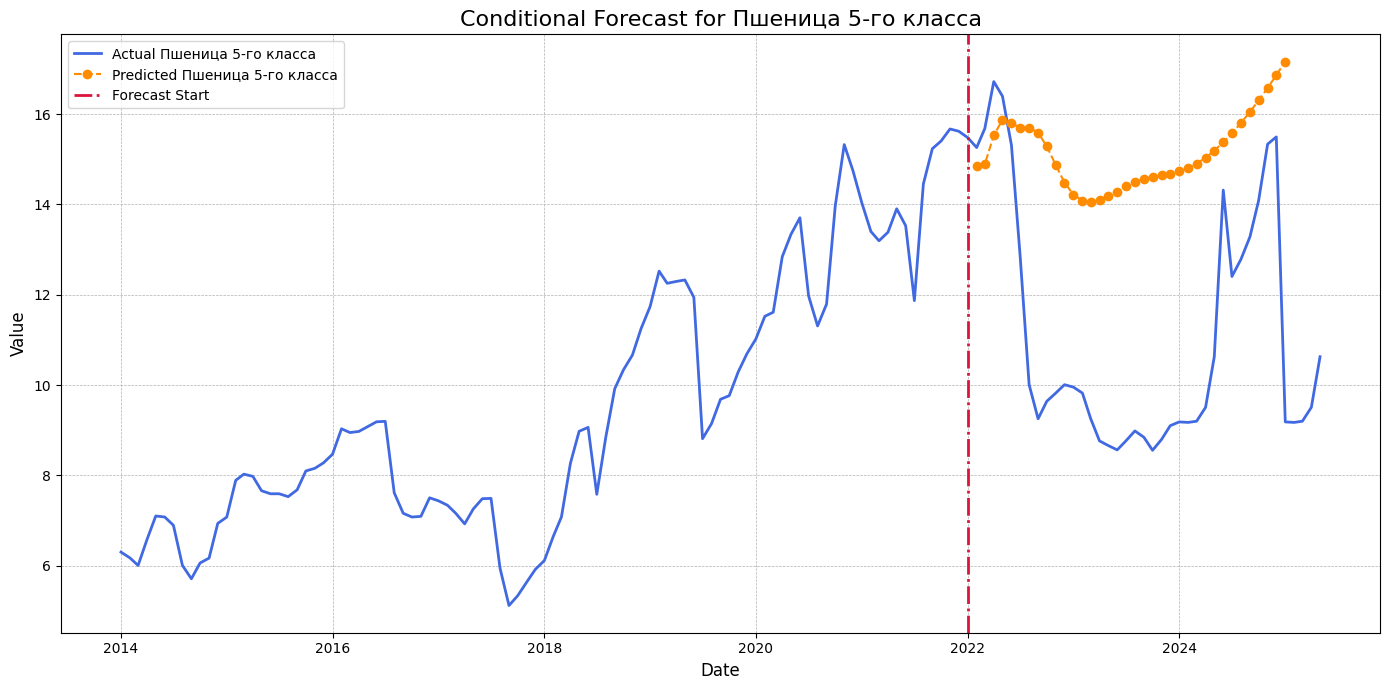

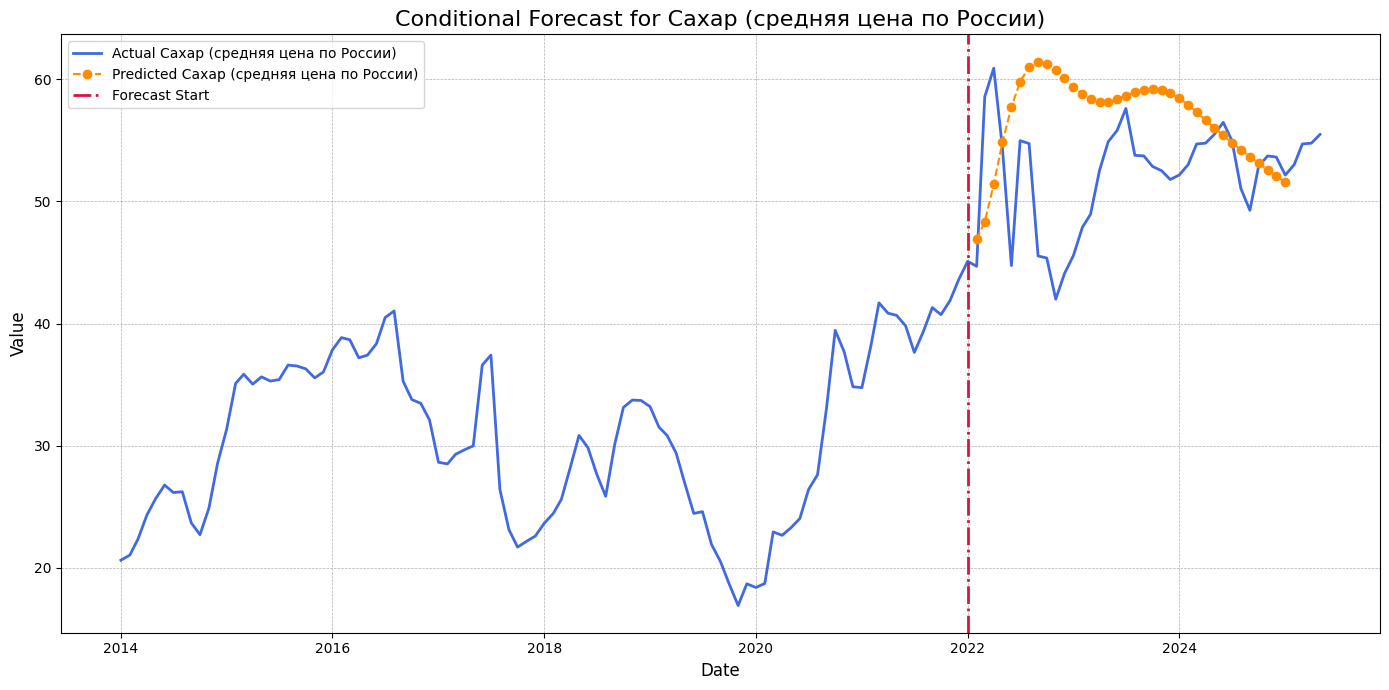

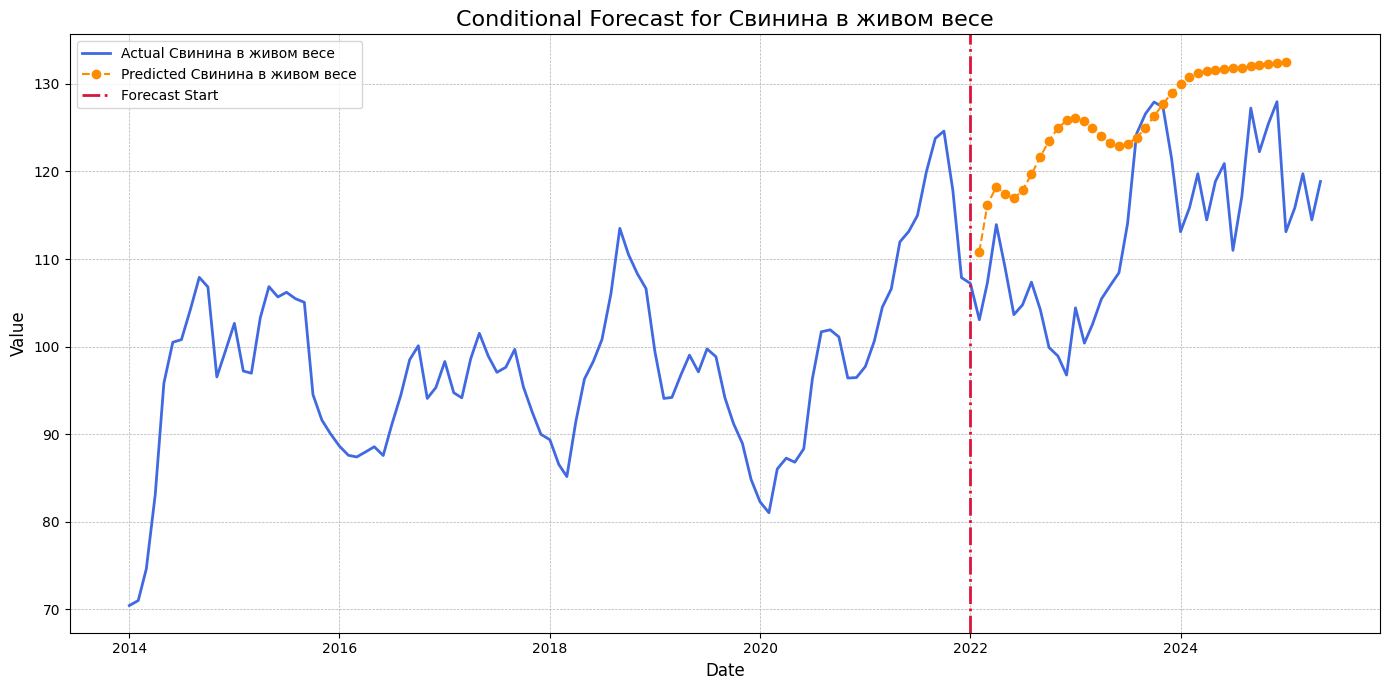

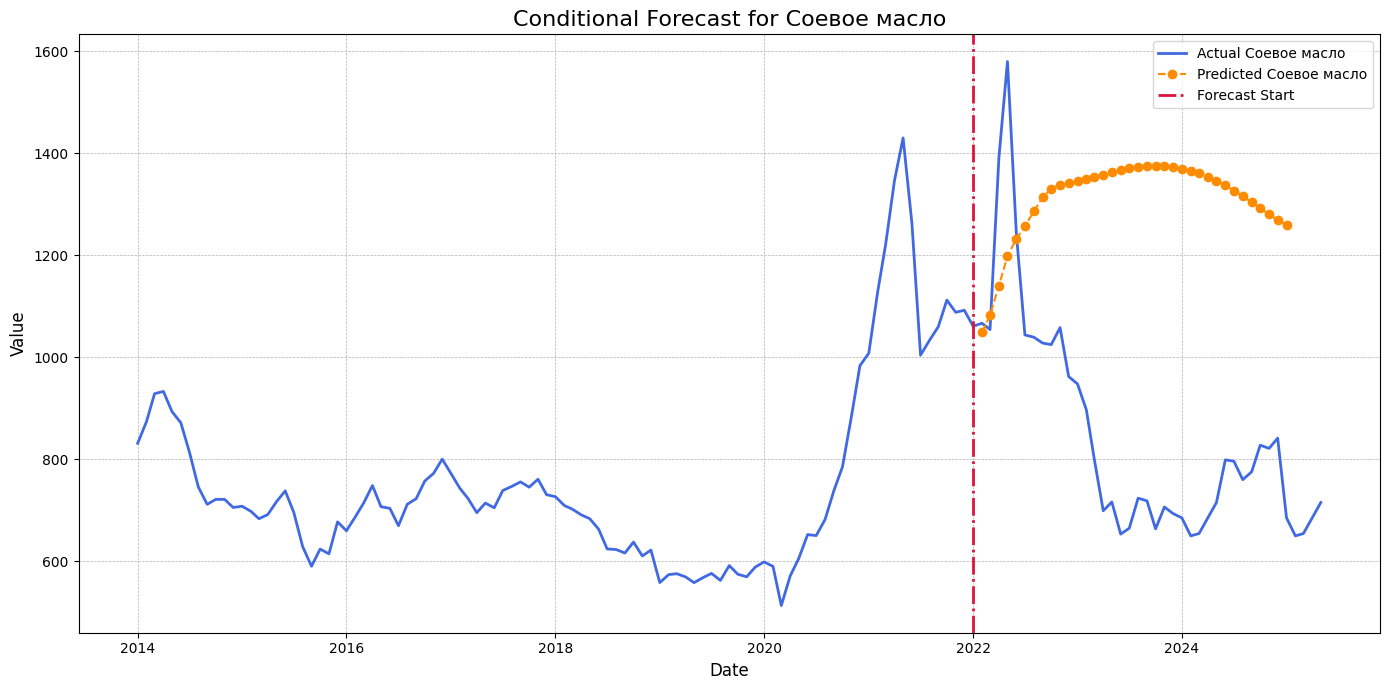

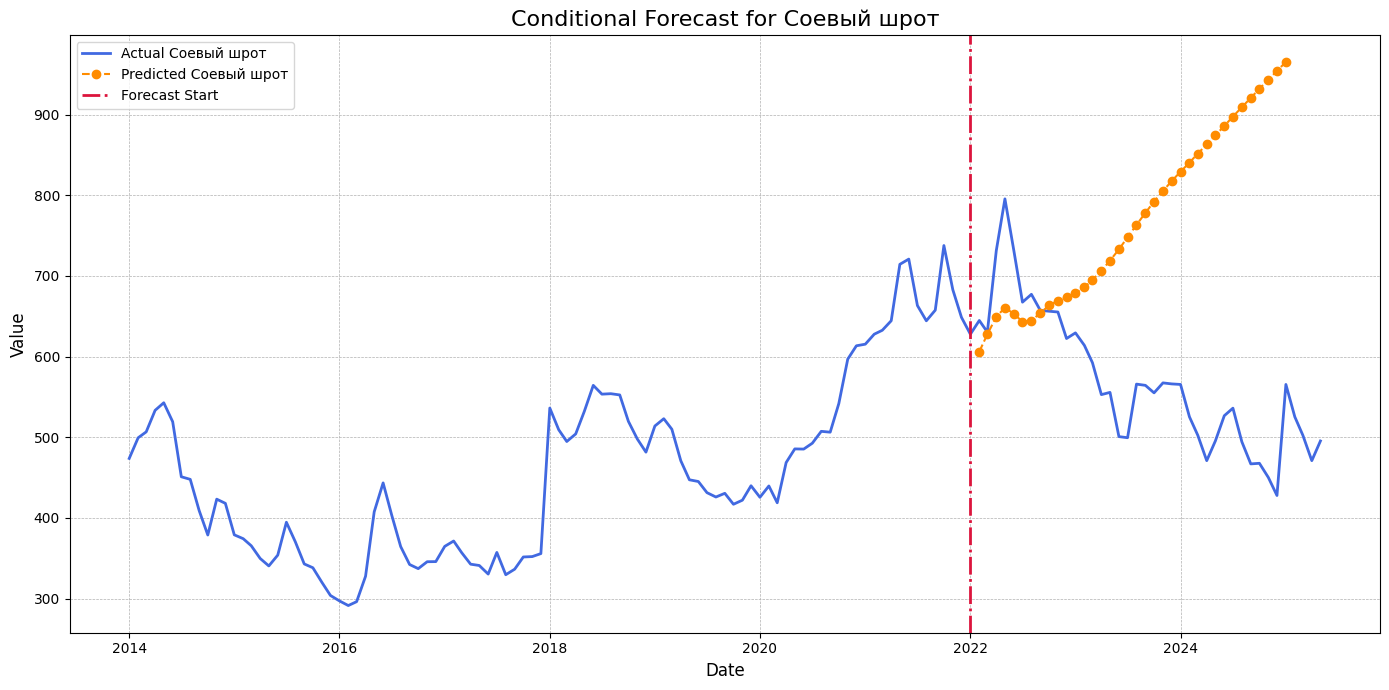

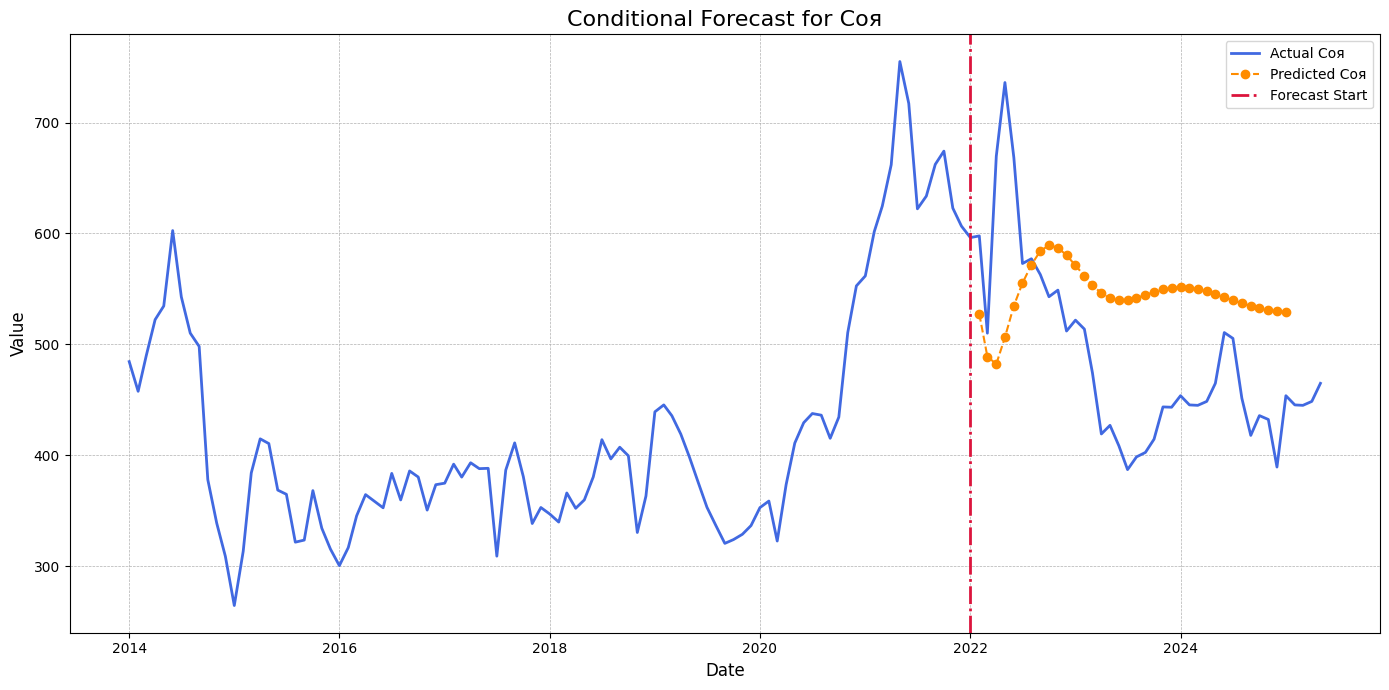

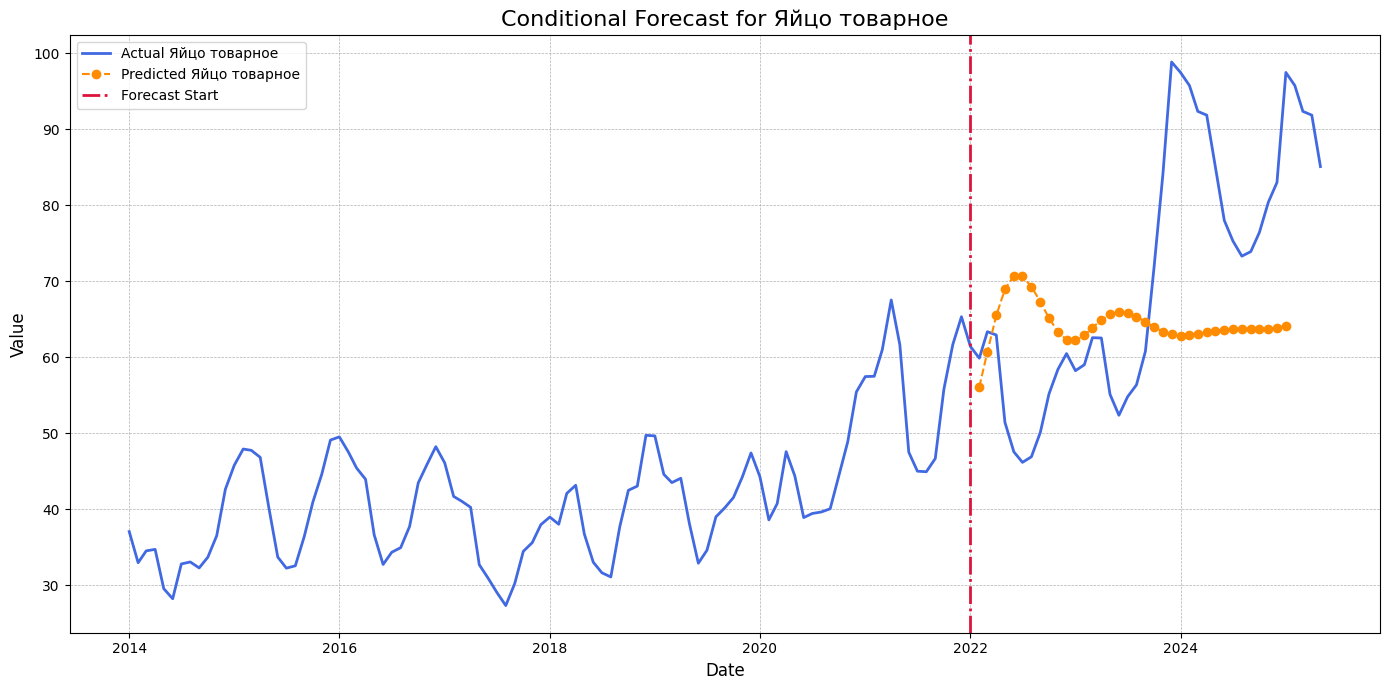

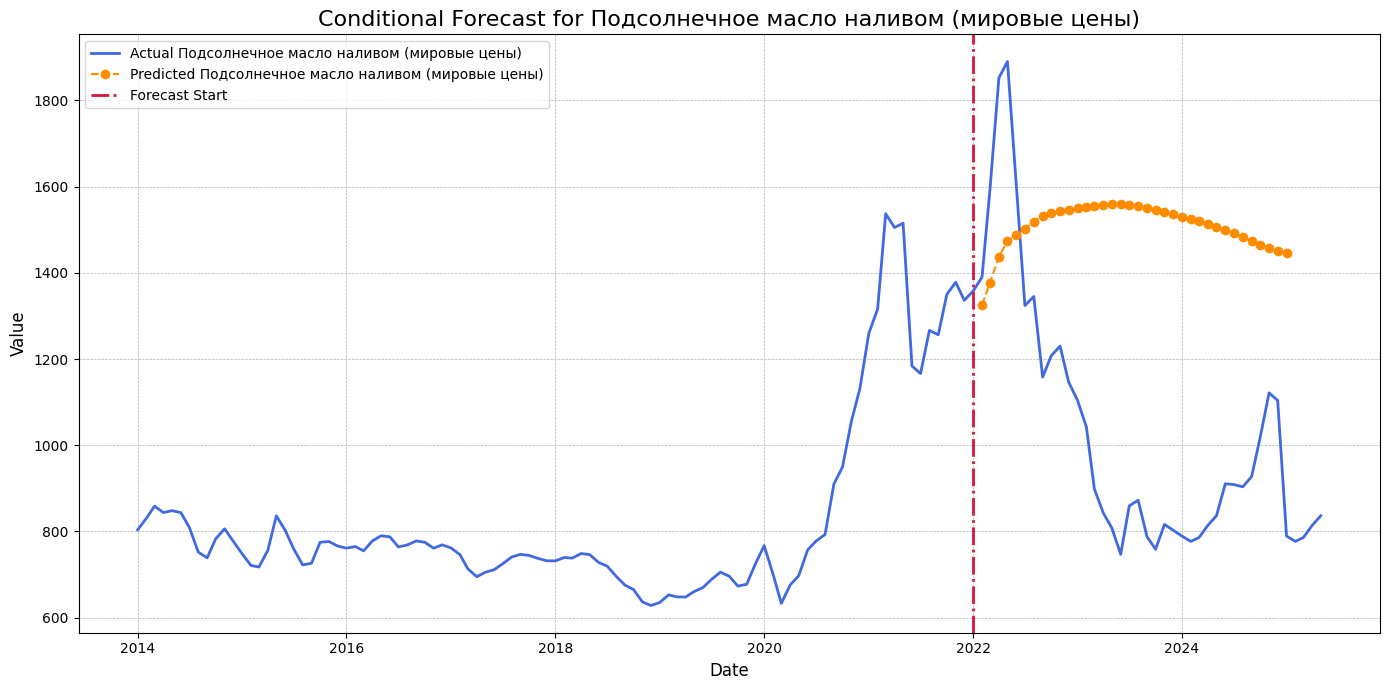

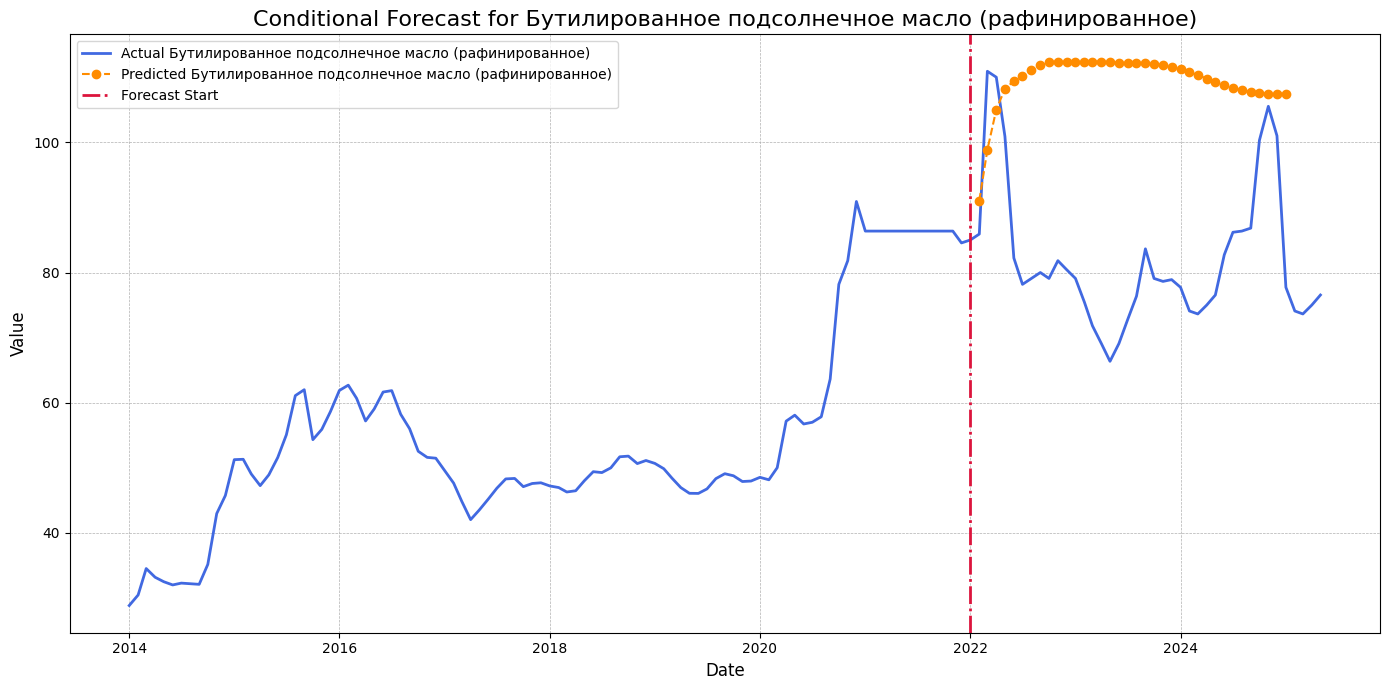

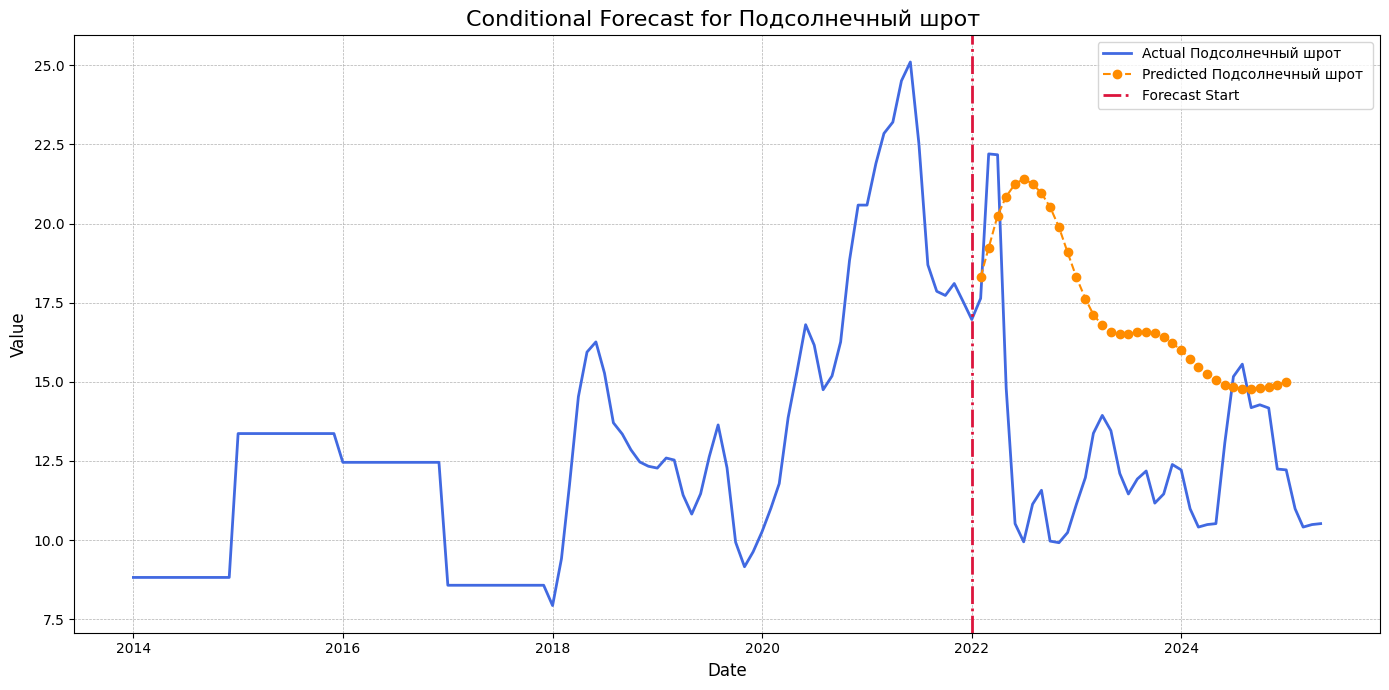

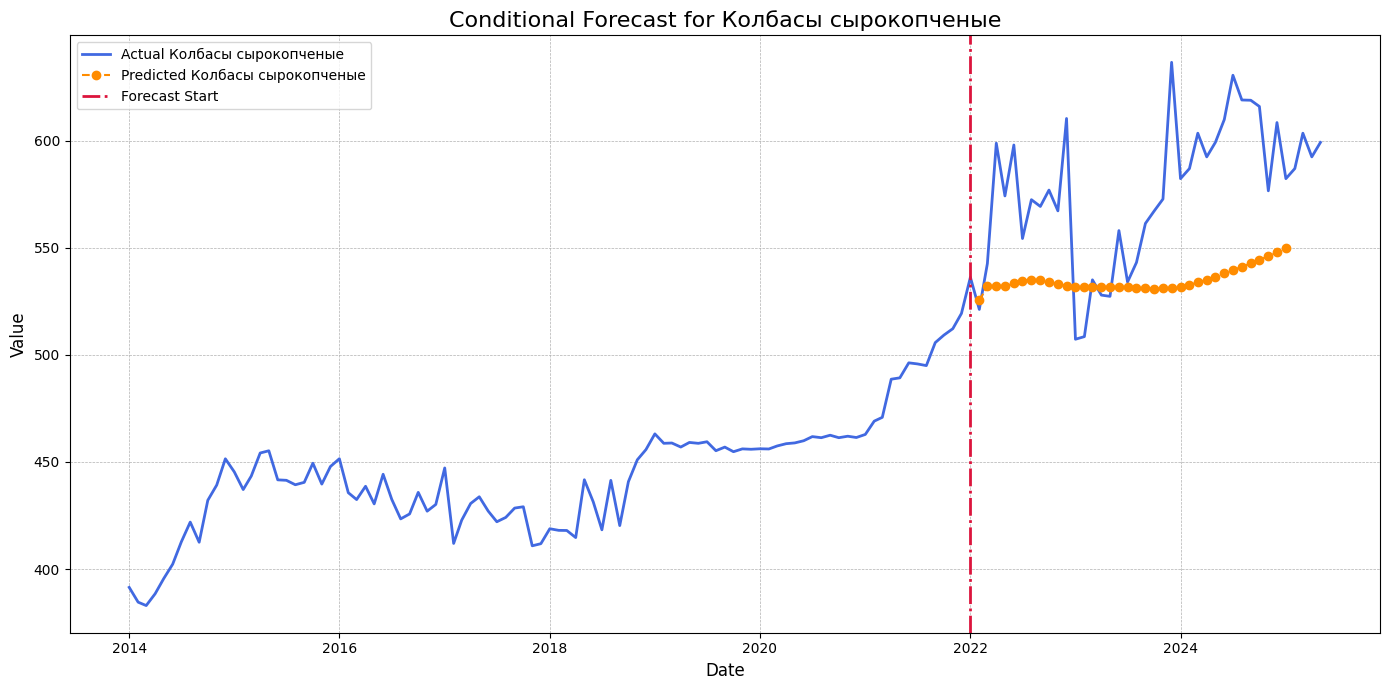

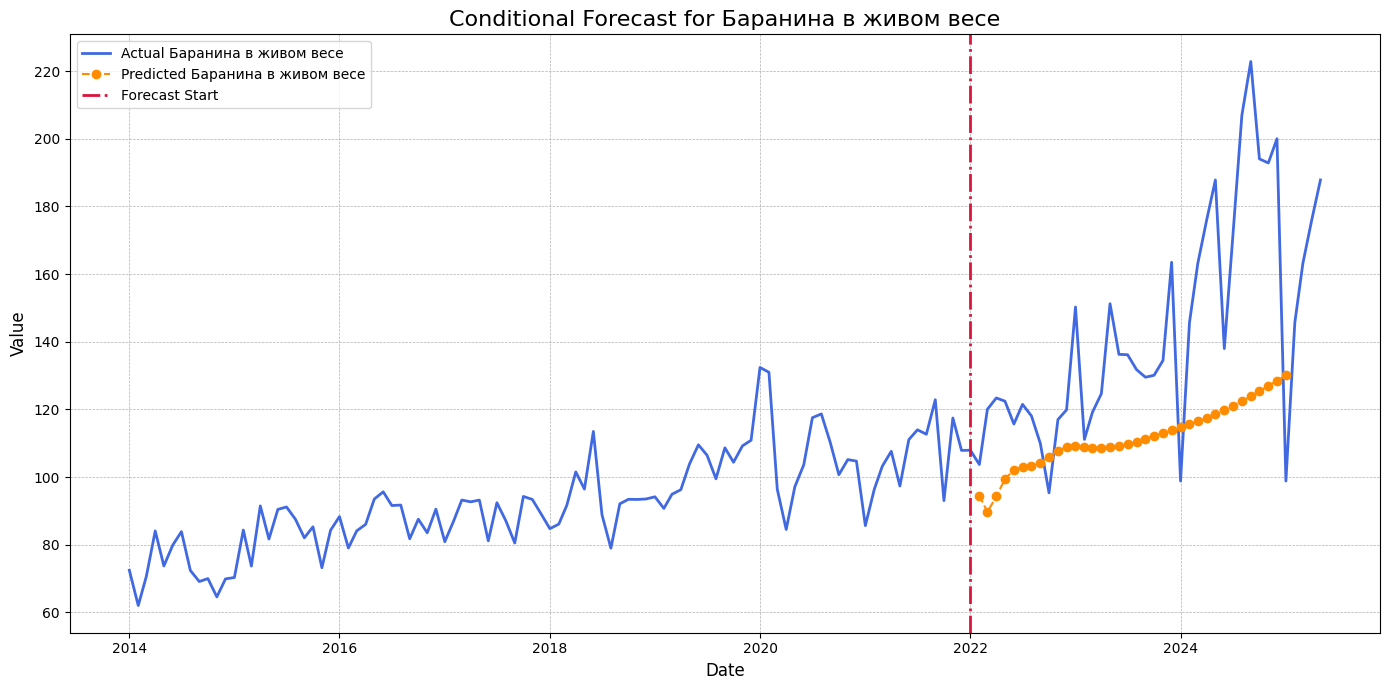

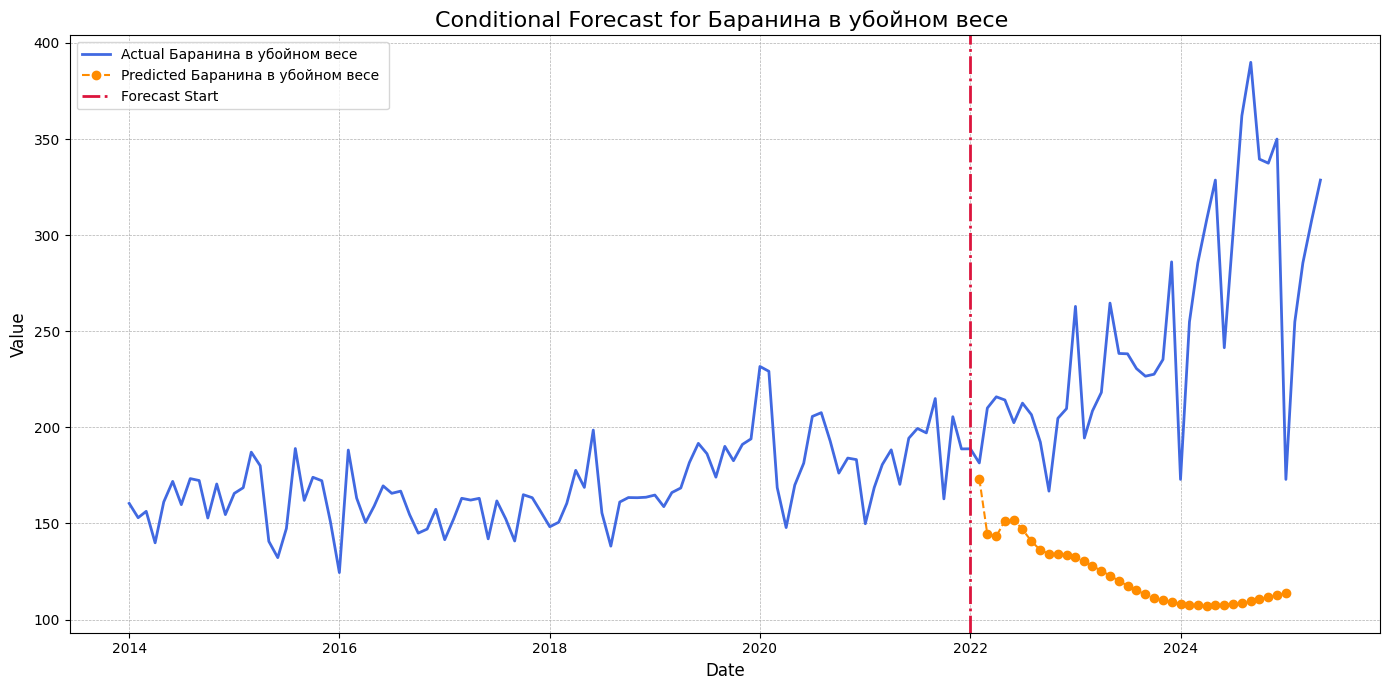

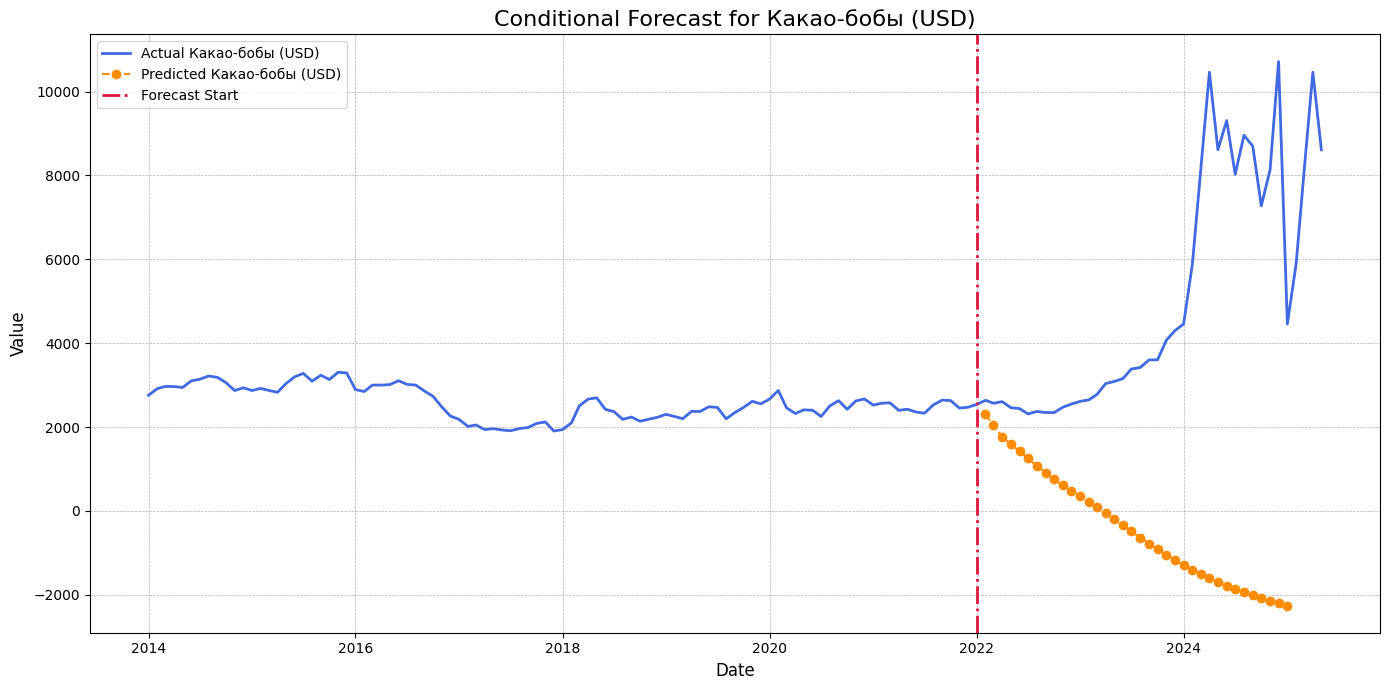

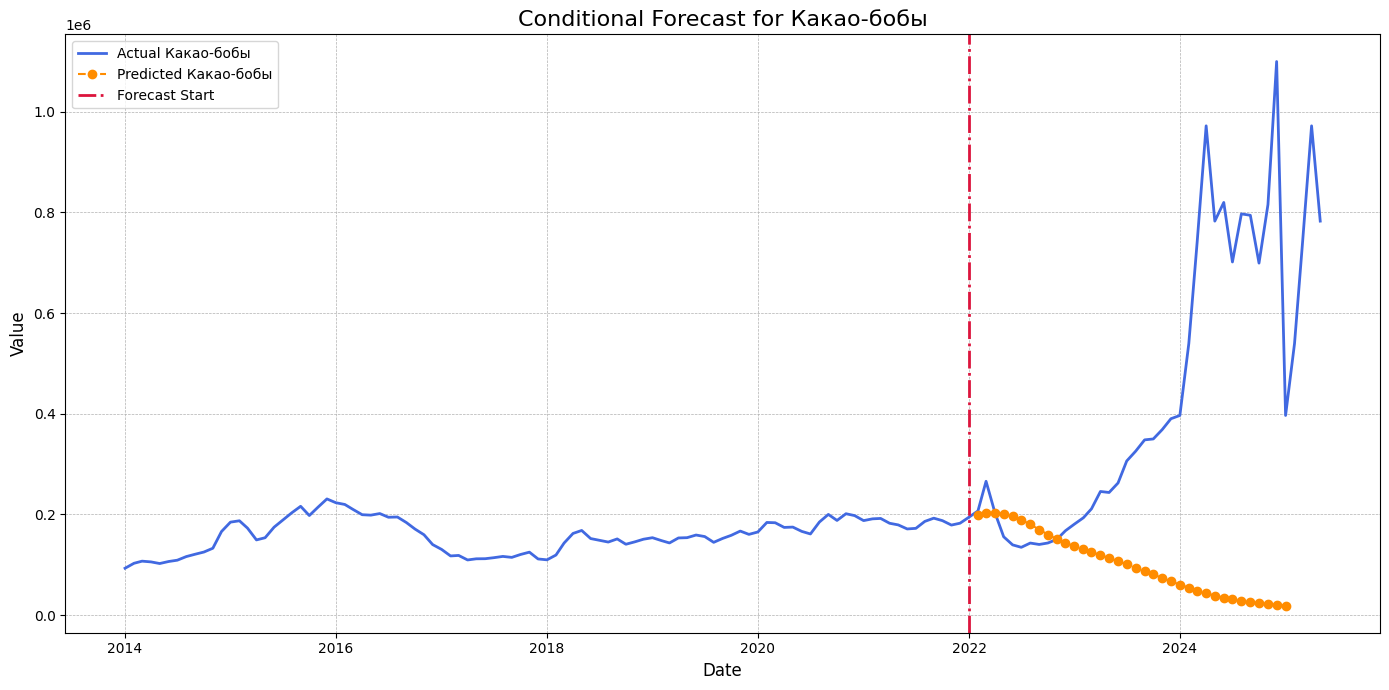

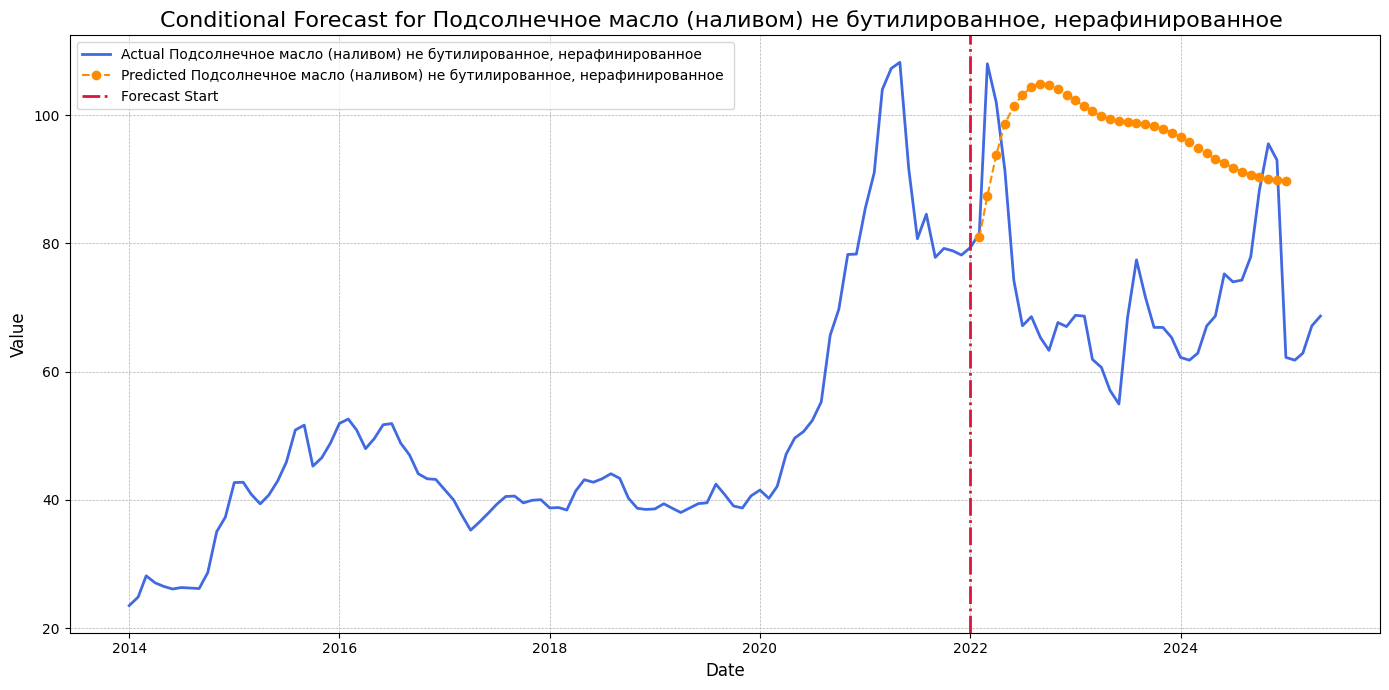

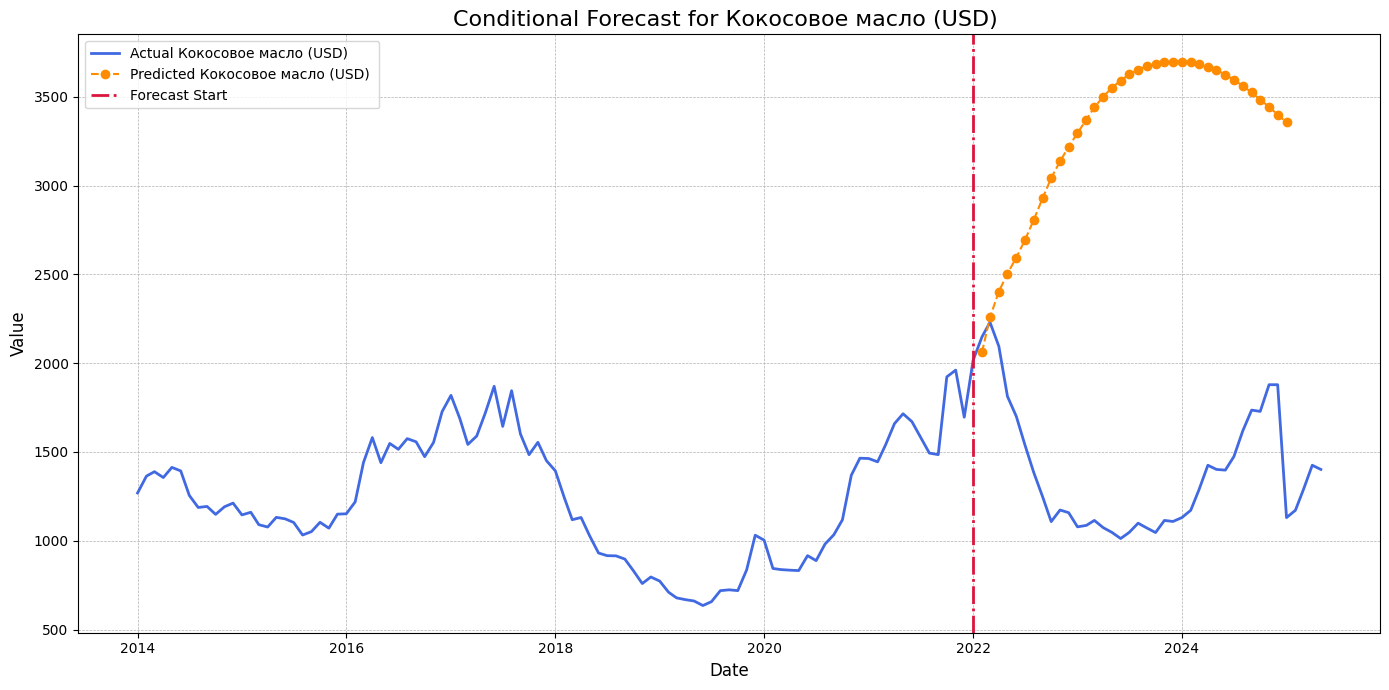

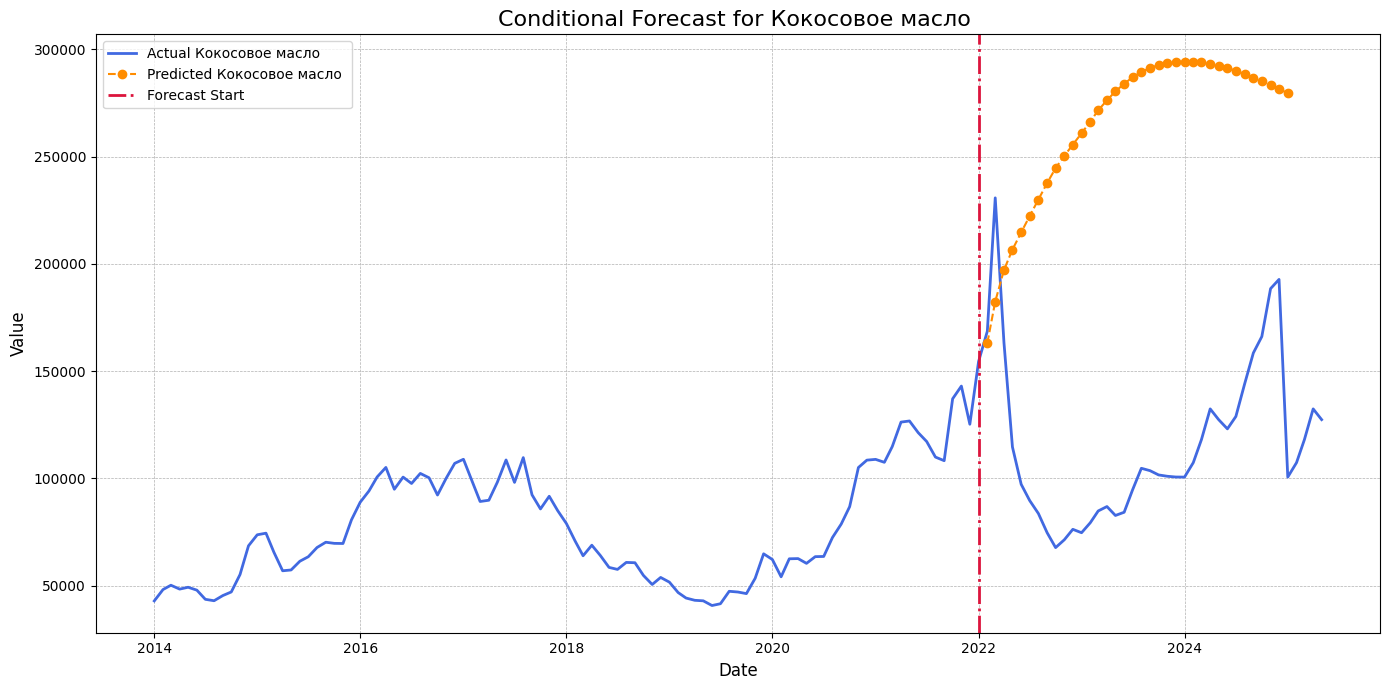

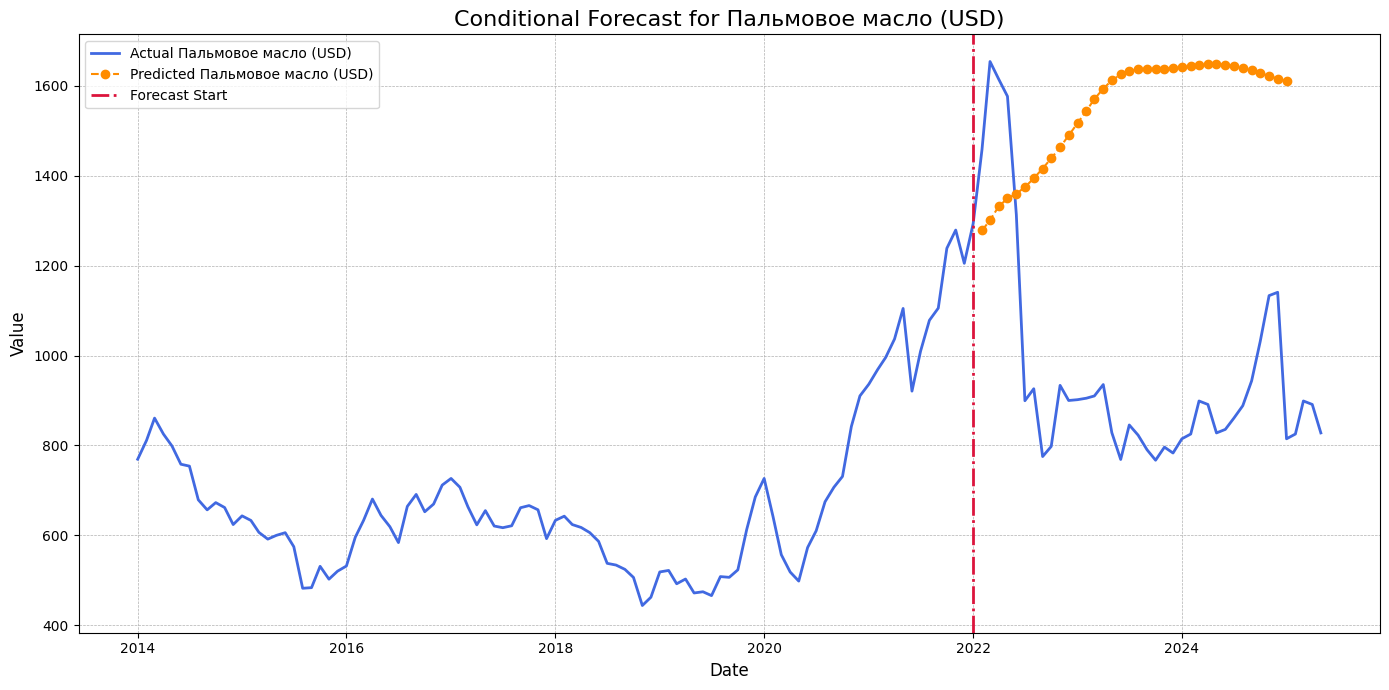

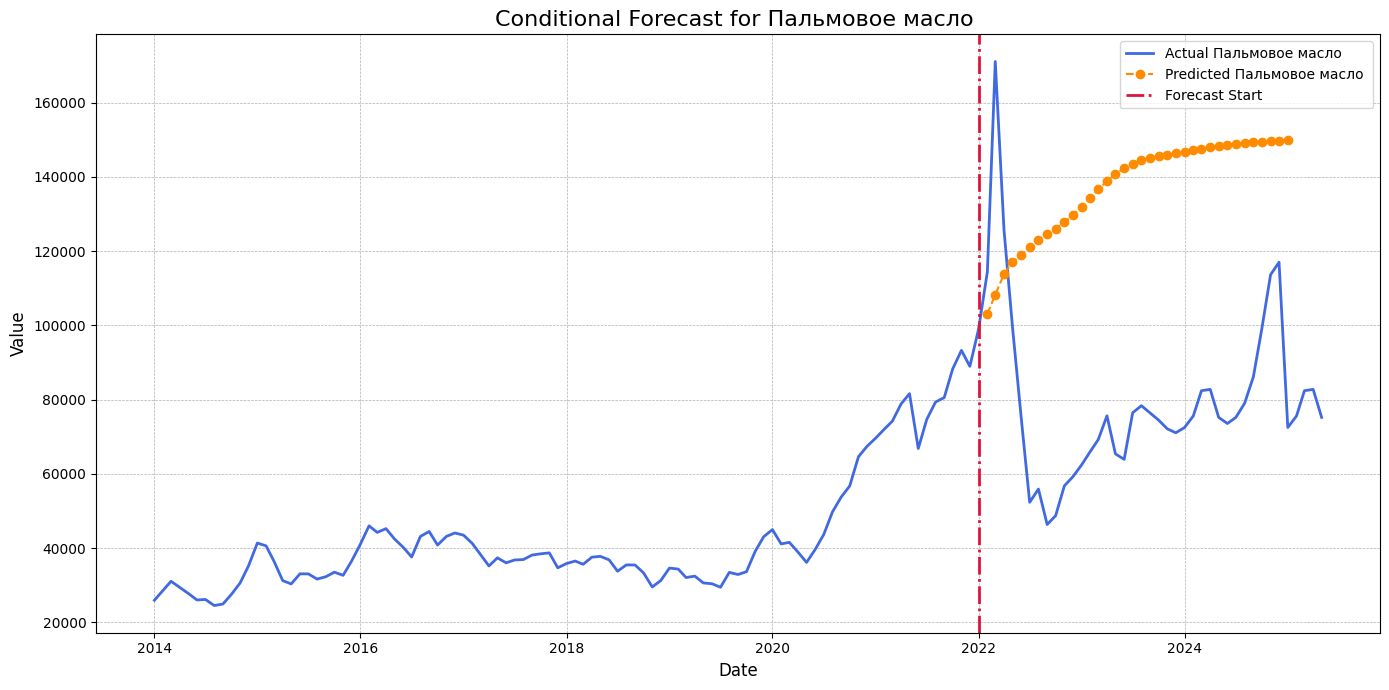

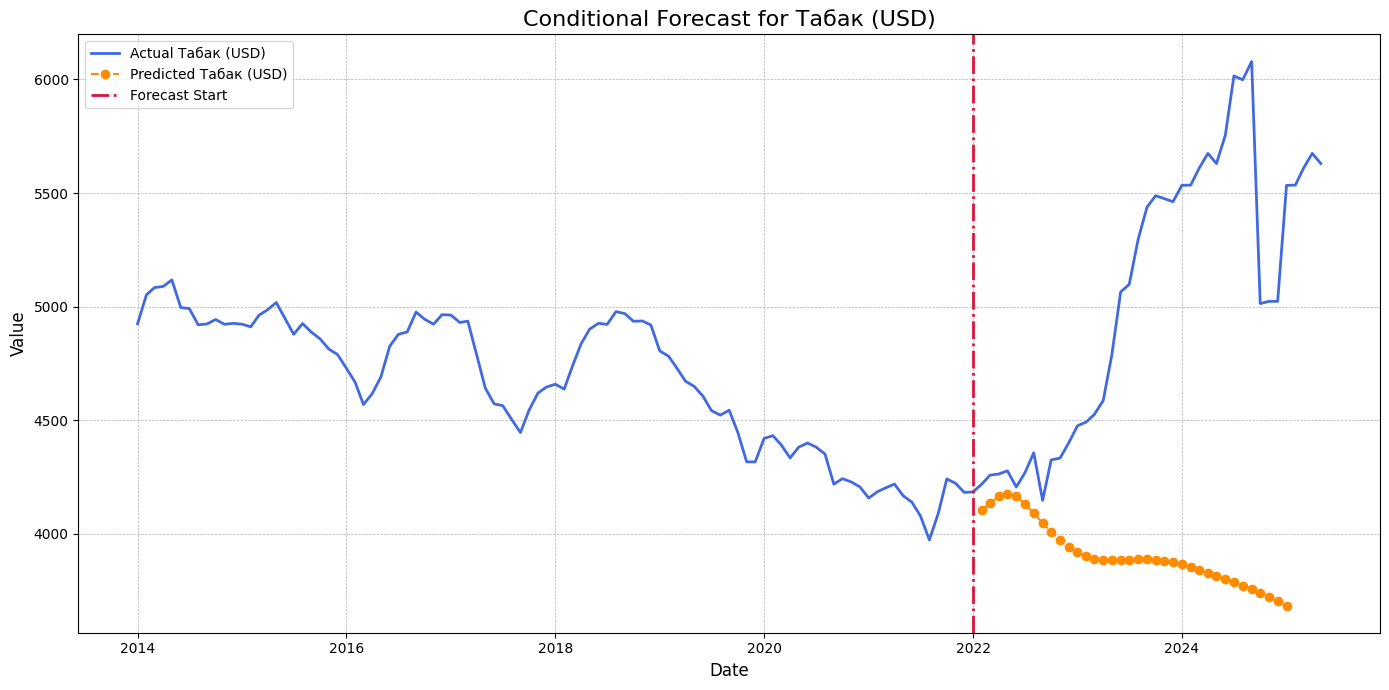

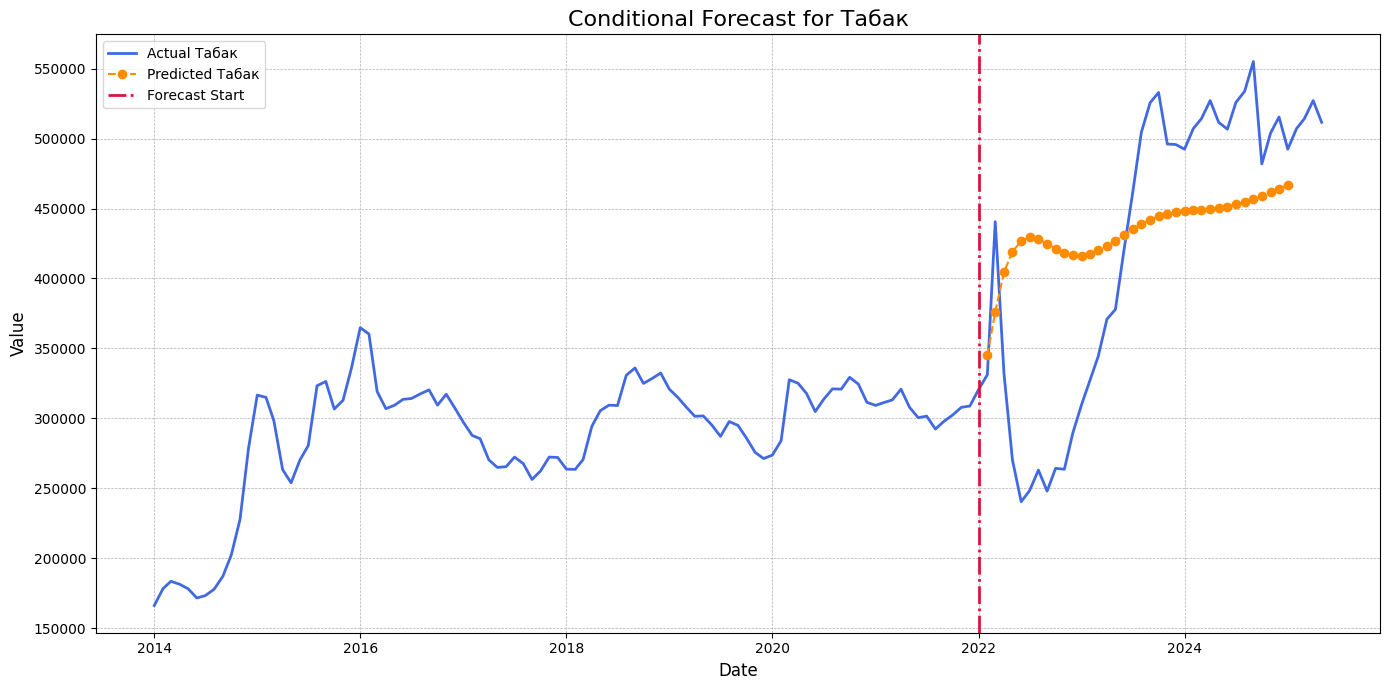

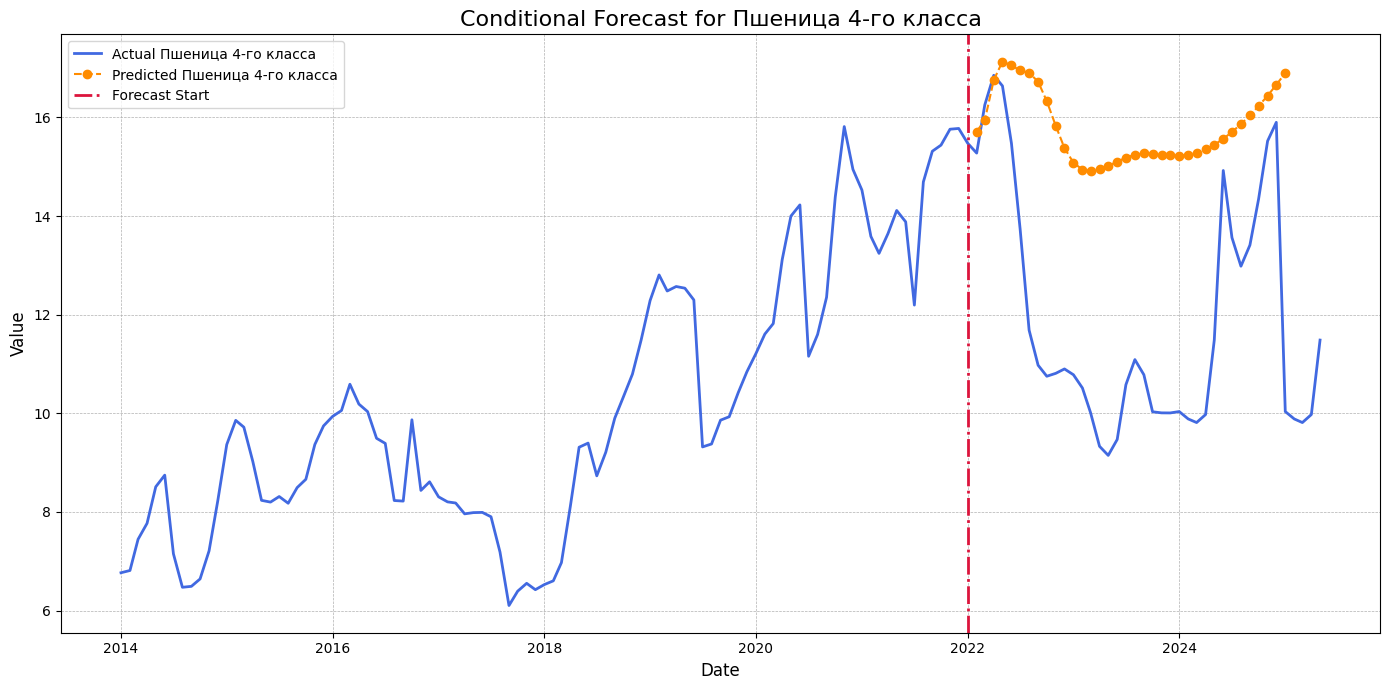

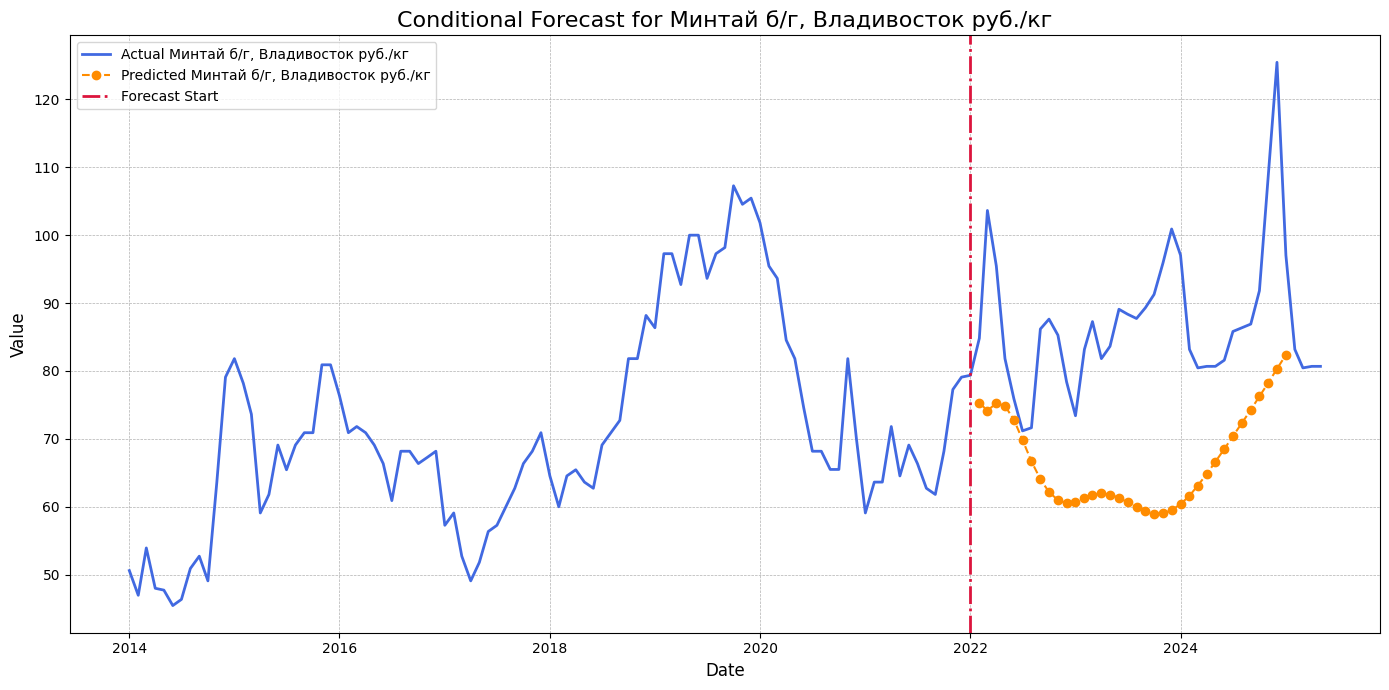

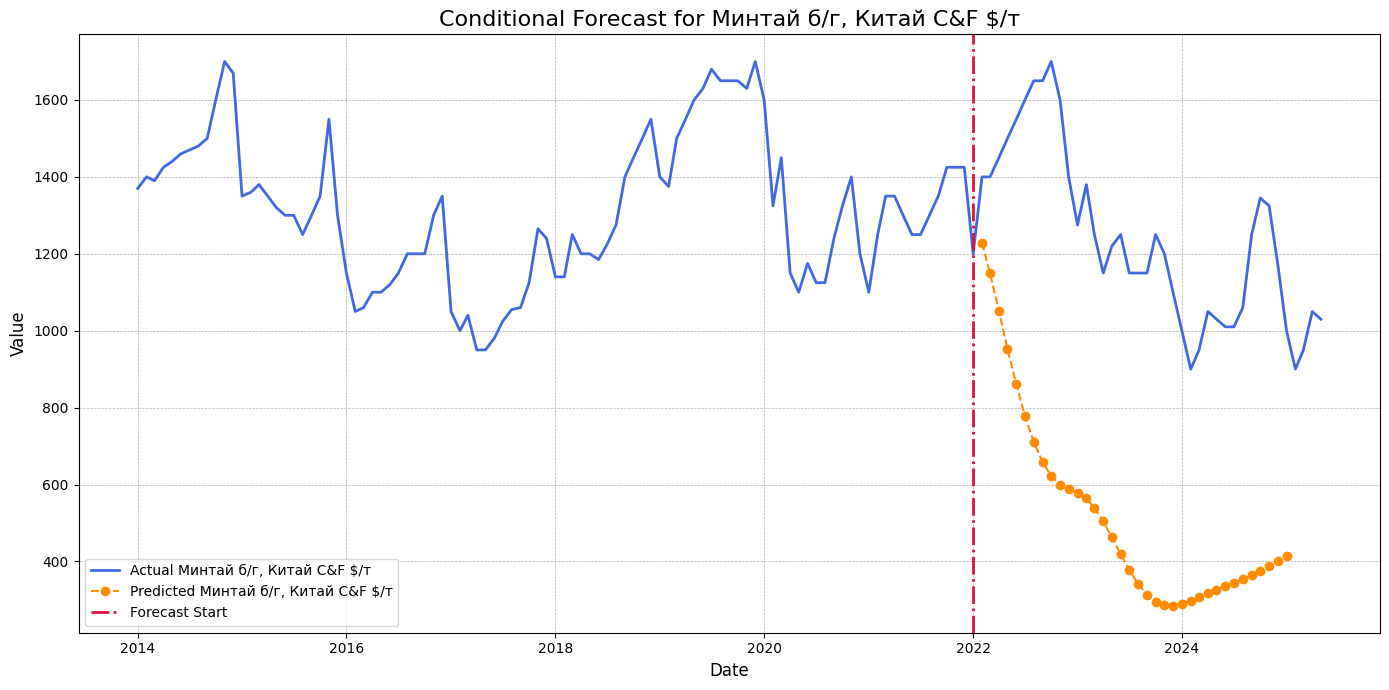

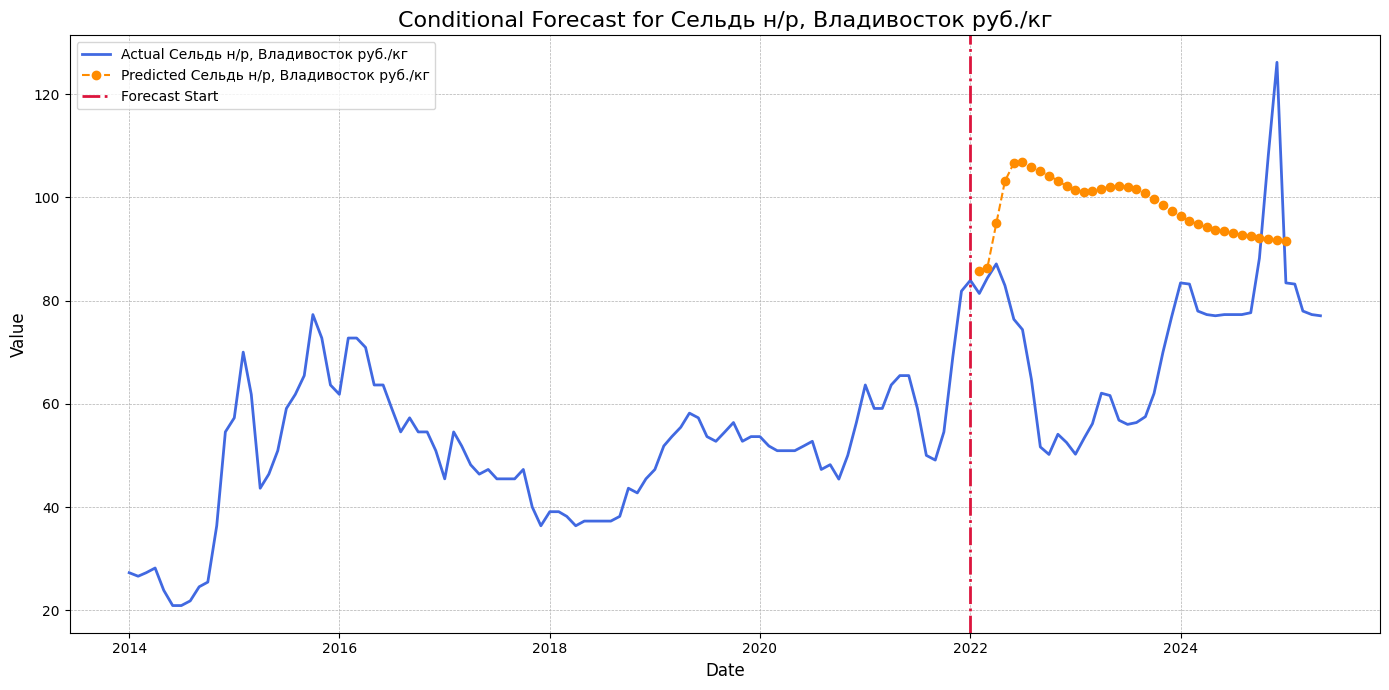

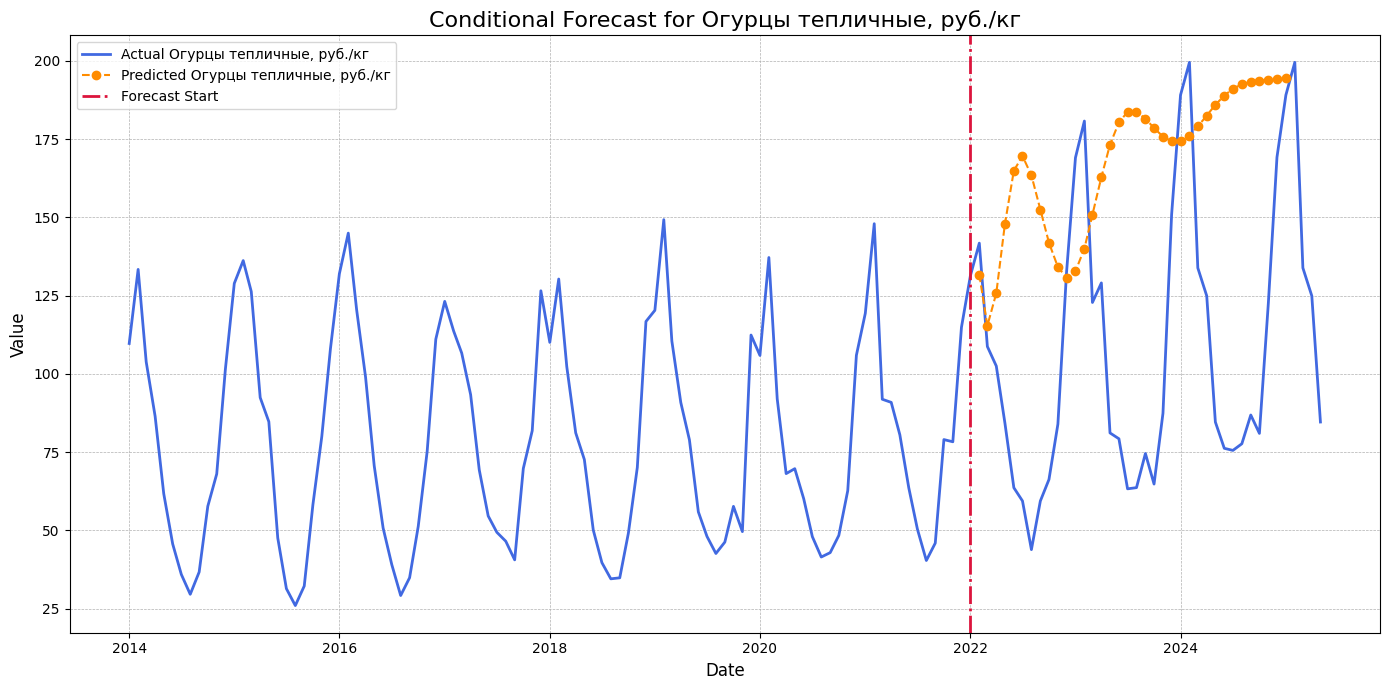

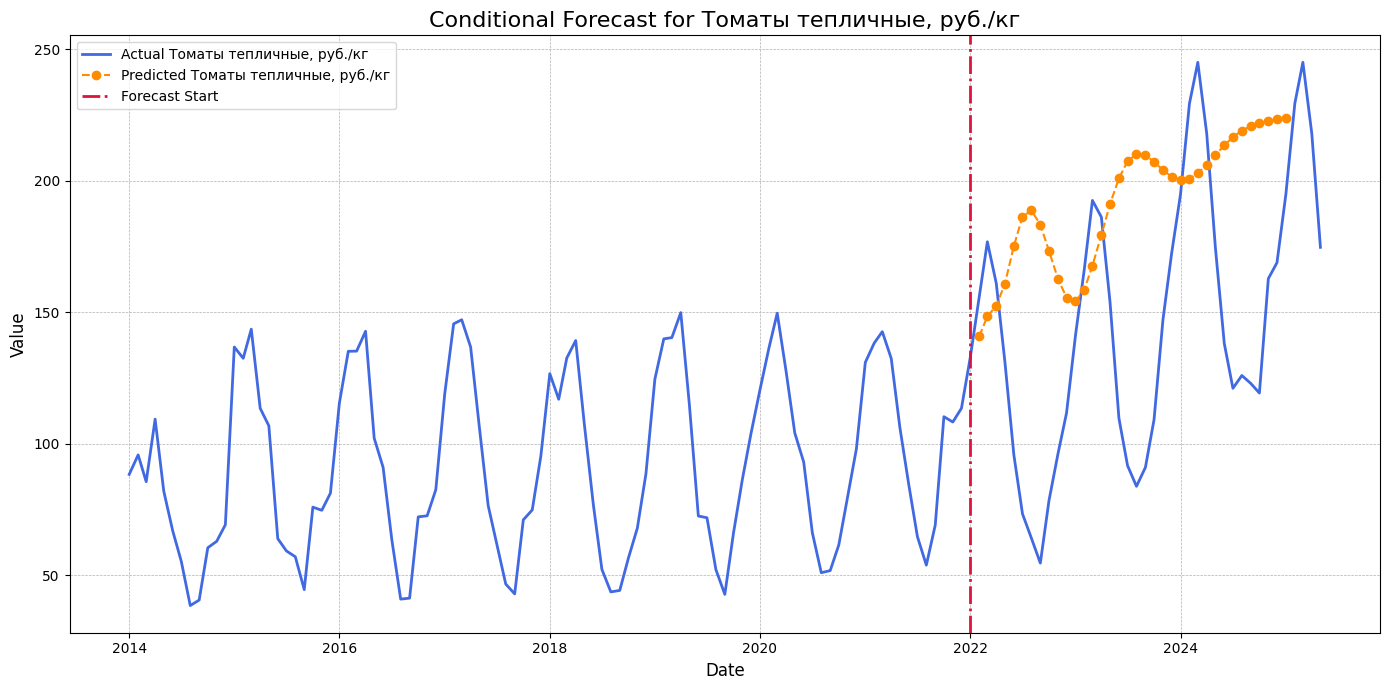

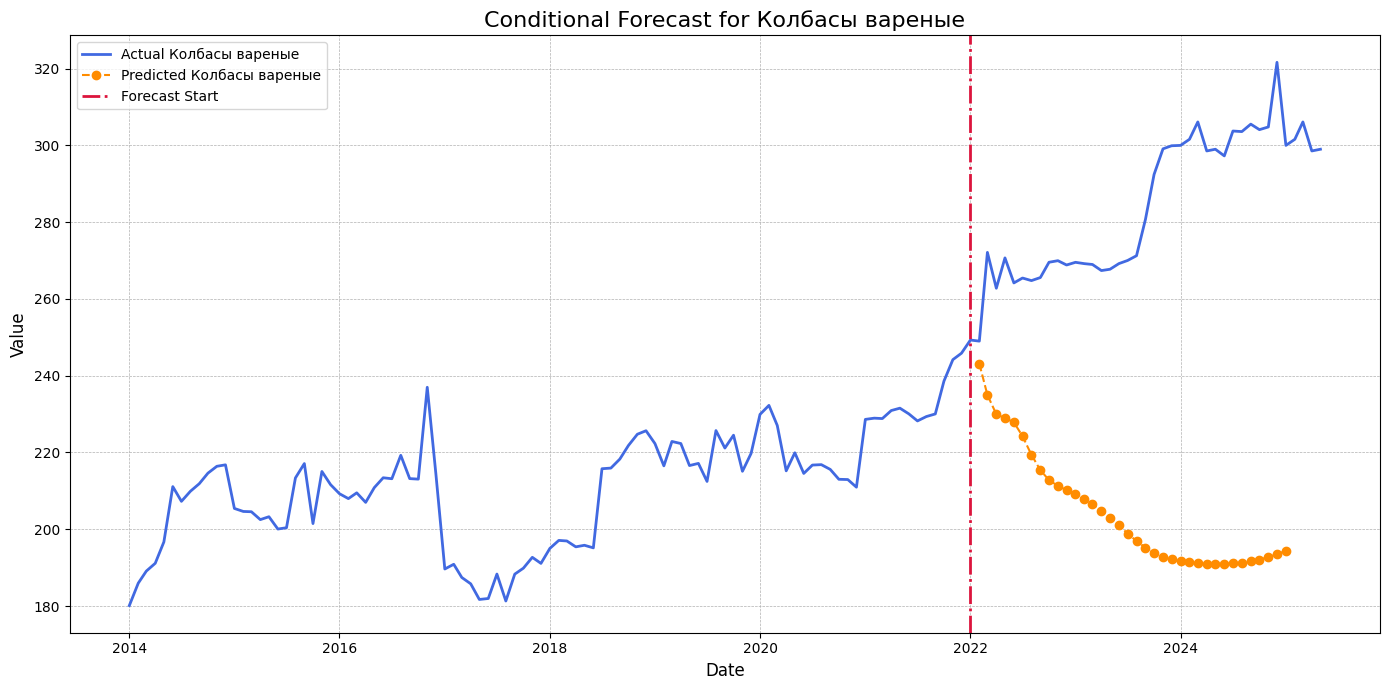

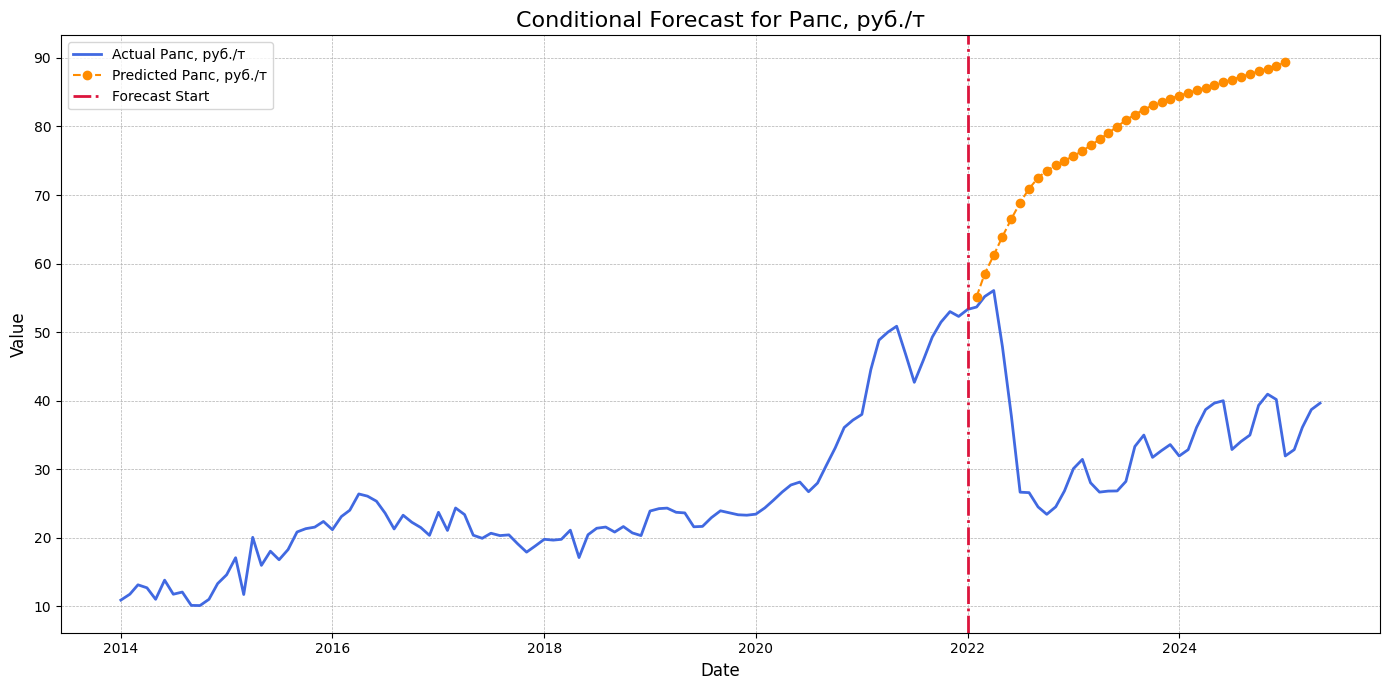

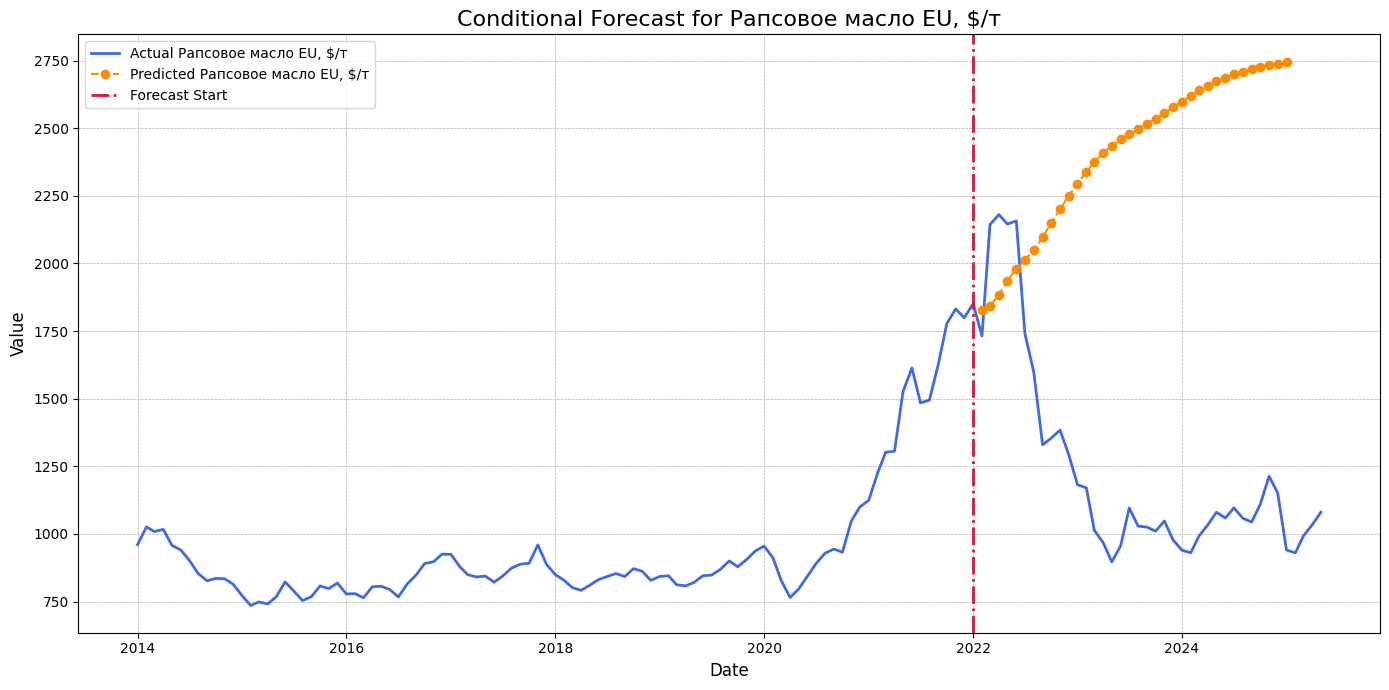

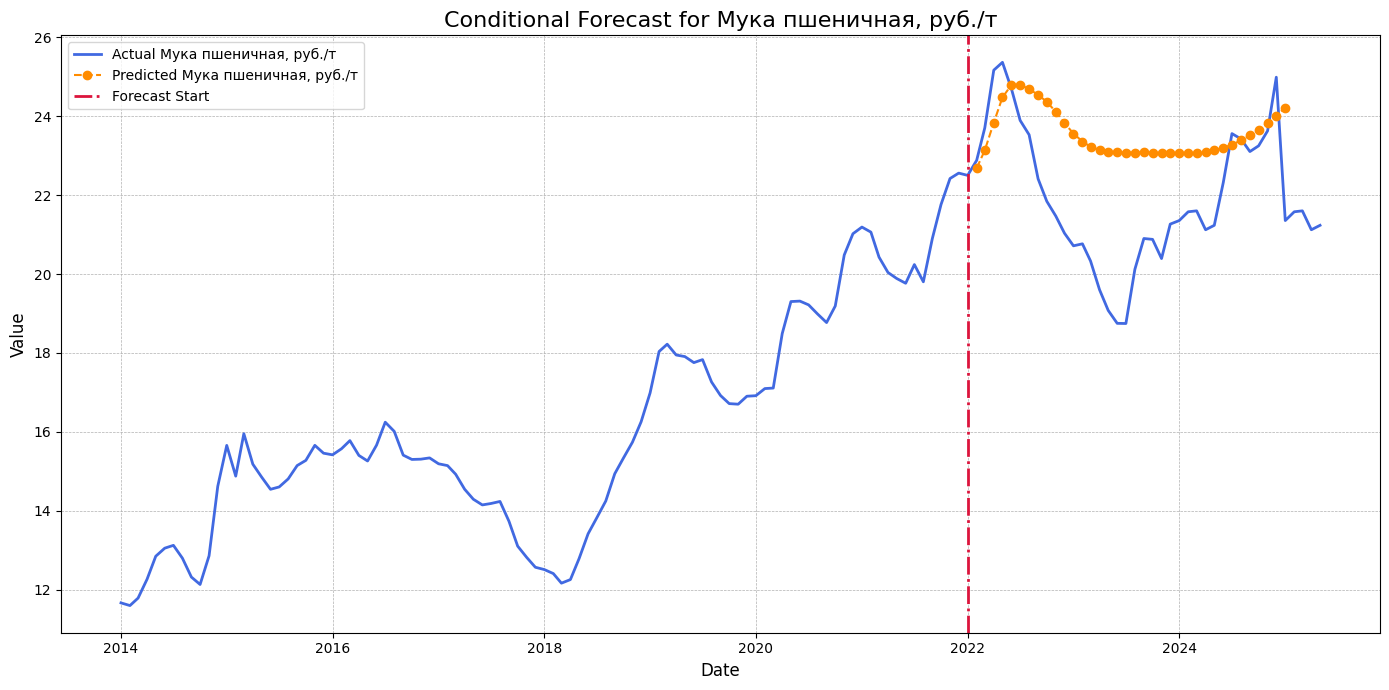

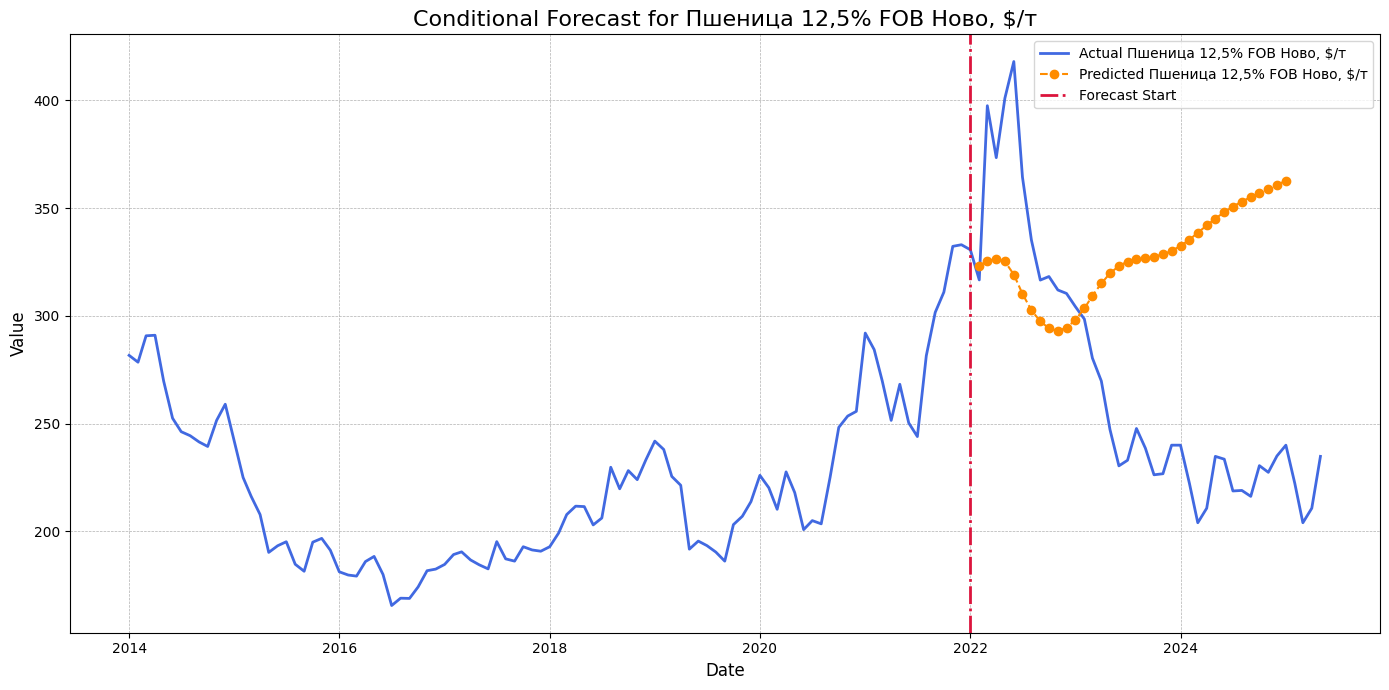

In [ ]:
plot_model_pred(
    model_class=VARReduceLinExtr,
    df=df,
    model_params={
        "regressor": Ridge(alpha=5, max_iter=20000),
        "lags": 1,
    },
    conditioning_col=df.columns[3],
    horizon=36,
    cutoff_date="2022-01-01",
)